# Library & Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


file_paths = {
    "Boston": "data/listings_bs.csv.gz",
    "Los Angeles": "data/listings_la.csv.gz",
    "New York City": "data/listings_ny.csv.gz",
    "San Francisco": "data/listings_sf.csv.gz",
    "Seattle": "data/listings_sea.csv.gz"
}
dfs = []
for city, path in file_paths.items():
    df = pd.read_csv(path, low_memory=False)
    df["city"] = city
    dfs.append(df)

airbnb = pd.concat(dfs, ignore_index=True)

In [2]:
airbnb_clean = airbnb.copy()

# clear $
airbnb_clean["price"] = (
    airbnb_clean["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
airbnb_clean["price"] = pd.to_numeric(airbnb_clean["price"], errors="coerce")

airbnb_clean = airbnb_clean[
    airbnb_clean["price"].notna() &
    (airbnb_clean["price"] > 0)
].copy()

airbnb_clean["log_price"] = np.log1p(airbnb_clean["price"])

## Final Feature Set

Target: price, log price

Features: (linear model would be different set)
1. accomodation, bedroom, bathroom, beds
2. minimum_nights
3. review_scores_rating, number_of_reviews
4. host_acceptance_rate, host_response_rate, host_has_profile_pic, host_years (~ superhost)
5. avalability_365
6. neigborhood_cleasensed (change to toursim)
7. room_type {drop hotel room and shared room (only keep entire and private only)}


In [3]:
# based on TripAdvisor, aligned with neighbourhood_cleansed in datasets
tourist_neighborhoods = {
    "Boston": [
        "North End", "Beacon Hill", "Back Bay",
        "Chinatown", "South Boston Waterfront", "South End",
        "Jamaica Plain", "Downtown", "South Boston", "Fenway"
    ],
    "Los Angeles": [
        "Downtown", "Chinatown", "Hollywood", "Silver Lake",
        "Koreatown", "Hollywood Hills", "Los Feliz",
        "Montecito Heights", "Echo Park", "Mid-Wilshire"
    ],
    "New York City": [
        "Midtown", "SoHo", "Greenwich Village", "Little Italy",
        "Chinatown", "Flatiron District", "Harlem",
        "Upper West Side", "Upper East Side", "Chelsea"
    ],
     "San Francisco": [
        "Chinatown", "North Beach", "Haight Ashbury",
        "Castro/Upper Market", "Western Addition", "Nob Hill",
        "Mission", "Marina", "Pacific Heights", "Russian Hill"
    ],
    "Seattle": [
        "Pioneer Square", "Lower Queen Anne", "Fremont",
        "Belltown", "Loyal Heights", "University District",
        "Genesee" # less than 10 neighborhood due to geological limitations
    ]
}

airbnb_clean["neighbourhood_cleansed"] = (
    airbnb_clean["neighbourhood_cleansed"].str.strip()
)

airbnb_clean["tourist_area"] = 0

for city, neighs in tourist_neighborhoods.items():
    mask = (
        (airbnb_clean["city"] == city) &
        (airbnb_clean["neighbourhood_cleansed"].isin(neighs))
    )
    airbnb_clean.loc[mask, "tourist_area"] = 1


In [4]:
# keep only main room types
airbnb_clean = airbnb_clean[
    airbnb_clean["room_type"].isin(["Entire home/apt", "Private room"])
].copy()

# clean boolean columns
bool_cols = [
    "host_has_profile_pic",
    "host_is_superhost",
    "host_identity_verified",
    "instant_bookable"
]

for col in bool_cols:
    if col in airbnb_clean.columns:
        airbnb_clean[col] = airbnb_clean[col].map({
            "t": 1, "f": 0,
            True: 1, False: 0
        })


# clean percentage columns
percent_cols = ["host_acceptance_rate", "host_response_rate"]

for col in percent_cols:
    if col in airbnb_clean.columns:
        airbnb_clean[col] = (
            airbnb_clean[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .replace("nan", np.nan)
        )
        airbnb_clean[col] = pd.to_numeric(airbnb_clean[col], errors="coerce") / 100


# host_since -> host_years
ref_time = pd.Timestamp("2025-09-01")
if "host_since" in airbnb_clean.columns:
    airbnb_clean["host_since"] = pd.to_datetime(
        airbnb_clean["host_since"], errors="coerce"
    )
    airbnb_clean["host_years"] = (
        (ref_time - airbnb_clean["host_since"]).dt.days / 365.25
        # use 365.25 instead of 365
        # this is because there is a leap year every four years
    )


# numeric cleaning
num_to_clean = [
    "accommodates", "bedrooms", "bathrooms", "beds",
    "minimum_nights", "review_scores_rating",
    "number_of_reviews", "availability_365"
]
for col in num_to_clean:
    if col in airbnb_clean.columns:
        airbnb_clean[col] = pd.to_numeric(airbnb_clean[col], errors="coerce")




In [5]:
# Final feature lists
numeric_features = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "minimum_nights",
    "review_scores_rating",
    "number_of_reviews",
    "host_acceptance_rate",
    "host_response_rate",
    "host_has_profile_pic",
    "host_years",
    "availability_365",
    "tourist_area"
]

categorical_features = [
    "room_type"
]

numeric_features = [c for c in numeric_features if c in airbnb_clean.columns]
categorical_features = [c for c in categorical_features if c in airbnb_clean.columns]
feature_cols = numeric_features + categorical_features

model_df = airbnb_clean[
    ["city", "price", "log_price"] + numeric_features + categorical_features + ["bathrooms_text"]
].copy()

print("Model data shape:", model_df.shape)
print(model_df["city"].value_counts())
print(model_df[["price", "log_price"]].describe())

Model data shape: (72481, 18)
city
Los Angeles      36388
New York City    20797
Seattle           6149
San Francisco     5689
Boston            3458
Name: count, dtype: int64
              price     log_price
count  72481.000000  72481.000000
mean     283.954112      5.125258
std     1189.925949      0.822840
min        8.000000      2.197225
25%       96.000000      4.574711
50%      157.000000      5.062595
75%      261.000000      5.568345
max    85000.000000     11.350418


In [6]:
model_df.isna().mean().sort_values(ascending=False)

review_scores_rating    0.244975
host_acceptance_rate    0.132559
host_response_rate      0.130310
host_has_profile_pic    0.018101
host_years              0.018101
beds                    0.001863
bedrooms                0.001628
bathrooms_text          0.000441
bathrooms               0.000331
room_type               0.000000
tourist_area            0.000000
availability_365        0.000000
city                    0.000000
price                   0.000000
minimum_nights          0.000000
accommodates            0.000000
log_price               0.000000
number_of_reviews       0.000000
dtype: float64

In [7]:
na_city = (
    model_df
    .groupby("city")
    .apply(lambda df: df.isna().mean())
)

for city in model_df["city"].unique():
    print(f"\n {city} ")
    display(
        model_df[model_df["city"] == city]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )


 Boston 


/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/2337558380.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.isna().mean())


review_scores_rating    0.202718
host_response_rate      0.041353
host_acceptance_rate    0.041064
host_years              0.000289
beds                    0.000289
host_has_profile_pic    0.000289
city                    0.000000
room_type               0.000000
tourist_area            0.000000
availability_365        0.000000
dtype: float64


 Los Angeles 


review_scores_rating    0.252995
host_acceptance_rate    0.118913
host_response_rate      0.115972
beds                    0.001511
bedrooms                0.000962
host_has_profile_pic    0.000467
host_years              0.000467
bathrooms_text          0.000440
bathrooms               0.000357
room_type               0.000000
dtype: float64

...

review_scores_rating    0.289465
host_acceptance_rate    0.199404
host_response_rate      0.185988
host_has_profile_pic    0.048036
host_years              0.048036
beds                    0.002404
bedrooms                0.002212
bathrooms_text          0.000481
bathrooms               0.000289
room_type               0.000000
dtype: float64


 San Francisco 


review_scores_rating    0.193883
host_response_rate      0.076112
host_acceptance_rate    0.049394
bedrooms                0.005273
beds                    0.004570
bathrooms_text          0.001055
bathrooms               0.000879
host_has_profile_pic    0.000176
host_years              0.000176
room_type               0.000000
dtype: float64


 Seattle 


host_response_rate      0.127013
review_scores_rating    0.118068
host_acceptance_rate    0.115629
host_years              0.047813
host_has_profile_pic    0.047813
bedrooms                0.001138
beds                    0.000488
city                    0.000000
room_type               0.000000
tourist_area            0.000000
dtype: float64

# Pre-train Processing

NA related process:
1. add column "has_review", if no review, then use median review_scores_rating to fill in
2. "host_response_rate", if na, use city-wise mean
3. "host_acceptance_rate", if na, use city-wise mean
4. "host_years", if na, use city-wise mean
5. "host_has_profile_pic", if na, use 0, default consider no pic
6. "bathroom", cross check with original "bedrooms_text" and fill in, if still na, PLACEHOLDER
7. "beds" & "bedrooms": since "accomodation" is no NA, use ones with full "beds" and "bedrooms" info to calculate ration, and then calculate those without "beds" and "bedrooms"


Only consider low 99% priced listings

In [8]:
model_ready = model_df.copy()

# review_scores_rating
city_review_median = model_ready.groupby("city")["review_scores_rating"].median()
model_ready["review_scores_rating"] = model_ready.apply(
    lambda row: city_review_median[row["city"]]
    if pd.isna(row["review_scores_rating"])
    else row["review_scores_rating"],
    axis=1,
)

# host_response_rate, host_acceptance_rate, host_years
for col in ["host_response_rate", "host_acceptance_rate", "host_years"]:
    city_mean = model_ready.groupby("city")[col].mean()
    model_ready[col] = model_ready.apply(
        lambda row, c=col: city_mean[row["city"]] if pd.isna(row[c]) else row[c],
        axis=1,
    )

# host_has_profile_pic, if NA, fill in with 0
model_ready["host_has_profile_pic"] = model_ready["host_has_profile_pic"].fillna(0).astype(int)

# bathrooms
def parse_bathrooms_text(text):
    """Extract a numeric bathroom count from strings like:
    '1 bath', '1.5 baths', 'Half-bath', 'Shared half-bath', etc."""
    if pd.isna(text):
        return np.nan
    text = str(text).lower().strip()
    if "half" in text:
        return 0.5
    match = re.search(r"(\d+\.?\d*)", text)
    if match:
        return float(match.group(1))
    return np.nan

parsed = model_ready["bathrooms_text"].apply(parse_bathrooms_text)
model_ready["bathrooms"] = model_ready["bathrooms"].fillna(parsed)
model_ready.drop(columns=["bathrooms_text"], inplace=True)





In [9]:
# Check how many are still missing after text-parse
print(
    "bathrooms still missing after text-parse:",
    model_ready["bathrooms"].isna().groupby(model_ready["city"]).sum()
)

bathrooms still missing after text-parse: city
Boston            0
Los Angeles      13
New York City     6
San Francisco     5
Seattle           0
Name: bathrooms, dtype: int64


In [10]:
model_ready.groupby(model_ready['city']).size()

city
Boston            3458
Los Angeles      36388
New York City    20797
San Francisco     5689
Seattle           6149
dtype: int64

In [11]:
# the number of still missing "bathrooms" ones is tiny
# drop them
model_ready = model_ready.dropna(subset=["bathrooms"]).copy()

In [12]:
# "beds" & "bedrooms"
complete_mask = model_ready["beds"].notna() & model_ready["bedrooms"].notna() & model_ready["accommodates"].notna()
complete = model_ready[complete_mask]

# note: private room vs entire home / apt are instinctly different
beds_ratio = (
    complete.groupby(["city", "room_type"])
    .apply(lambda g: (g["beds"] / g["accommodates"]).median())
    .to_dict()
)
bedrooms_ratio = (
    complete.groupby(["city", "room_type"])
    .apply(lambda g: (g["bedrooms"] / g["accommodates"]).median())
    .to_dict()
)

# Fallback ratios: city-only (in case a city×room_type combo has no complete rows)
beds_ratio_city = (
    complete.groupby("city")
    .apply(lambda g: (g["beds"] / g["accommodates"]).median())
    .to_dict()
)
bedrooms_ratio_city = (
    complete.groupby("city")
    .apply(lambda g: (g["bedrooms"] / g["accommodates"]).median())
    .to_dict()
)

def impute_from_ratio(row, col, ratio_lookup, fallback_lookup):
    if pd.notna(row[col]):
        return row[col]
    key = (row["city"], row["room_type"])
    ratio = ratio_lookup.get(key, fallback_lookup.get(row["city"], 0.5))
    imputed = round(ratio * row["accommodates"])
    return max(imputed, 1)  # at least 1

model_ready["beds"] = model_ready.apply(
    impute_from_ratio, col="beds",
    ratio_lookup=beds_ratio, fallback_lookup=beds_ratio_city,
    axis=1,
)
model_ready["bedrooms"] = model_ready.apply(
    impute_from_ratio, col="bedrooms",
    ratio_lookup=bedrooms_ratio, fallback_lookup=bedrooms_ratio_city,
    axis=1,
)

/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3675950194.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["beds"] / g["accommodates"]).median())
/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3675950194.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["bedrooms"] / g["accommodates"]).median())
/var/folders/vq/njtfhfys07xb0tb

In [13]:
# keep only the bottom 99% by price
price_top = model_ready["price"].quantile(0.99)
model_ready = model_ready[model_ready["price"] <= price_top].copy()

# recompute log price
model_ready["log_price"] = np.log1p(model_ready["price"])

## Sanity Check

In [14]:
print("shape:", model_ready.shape)

print("\nRemaining NAs ")
remaining_na = model_ready.isna().sum()
remaining_na = remaining_na[remaining_na > 0]
if remaining_na.empty:
    print("  No NAs remaining ")
else:
    print(remaining_na)

print("\nPrice cap applied ")
print(f"  Cap at 99th pct: ${price_top:,.2f}")
print(f"  Price range: ${model_ready['price'].min():.2f} – ${model_ready['price'].max():.2f}")

print("\nCity counts after filtering ")
print(model_ready["city"].value_counts())

shape: (71732, 17)

Remaining NAs 
  No NAs remaining 

Price cap applied 
  Cap at 99th pct: $1,916.76
  Price range: $8.00 – $1915.00

City counts after filtering 
city
Los Angeles      35817
New York City    20675
Seattle           6137
San Francisco     5650
Boston            3453
Name: count, dtype: int64


# Training

## Baseline

In [15]:
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr


import os
import joblib

In [16]:
# output dir
RESULTS_DIR = "results/baseline"
MODEL_DIR = "saved_models/baseline"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


In [17]:
# helper func
def clean_name(s):
    return (
        str(s)
        .strip()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )



In [18]:
# numeric features: use median to fill in NAs and standarized to z(0,1)
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
# categorical features: use mode to fill in NAs and apply one-hot encoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


In [19]:
models = {
    "Mean_Baseline": DummyRegressor(strategy="mean"),
    "Median_Baseline": DummyRegressor(strategy="median"),
    "Linear_Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=1003),
    "Lasso": Lasso(alpha=0.001, max_iter=10000, random_state=1003),
}


In [20]:
def metrics_on_price(y_true_log, y_pred_log):
    """
    Convert log-price back to price scale before evaluation.
    """

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    medae = np.median(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)

    rho = spearmanr(y_true, y_pred).statistic
    if np.isnan(rho):
        rho = np.nan

    error = y_pred - y_true

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Median_AE": medae,
        "R2": r2,
        "Spearman": rho,
        "Mean_Error": np.mean(error),
        "Overprice_Rate": np.mean(error > 0),
        "Underprice_Rate": np.mean(error < 0),
        "Within_25pct_Error": np.mean(np.abs(error) <= 0.25 * y_true),
        "Within_50pct_Error": np.mean(np.abs(error) <= 0.50 * y_true),
    }

In [21]:
# within-city cross-validation
baseline_results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for city in sorted(model_ready["city"].unique()):

    city_df = model_ready[model_ready["city"] == city].copy()

    X = city_df[feature_cols]
    y = city_df["log_price"].values

    for model_name, estimator in models.items():

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):

            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]

            y_train = y[train_idx]
            y_val = y[val_idx]

            pipe = Pipeline([
                ("prep", preprocessor),
                ("model", estimator),
            ])

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_val)

            m = metrics_on_price(y_val, y_pred)

            baseline_results.append({
                "Experiment": "baseline_within_city_cv",
                "Train_City": city,
                "Test_City": city,
                "Model": model_name,
                "Fold": fold,
                "N_train": len(X_train),
                "N_val": len(X_val),
                **m
            })


baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df.head())

/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3365915470.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).statistic
/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3365915470.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).statistic
/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3365915470.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).statistic
/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3365915470.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(y_true, y_pred).statistic
/var/folders/vq/njtfhfys07xb0tbx1f677q_c0000gn/T/ipykernel_81270/3365915470.py:14: ConstantInputWarning: An input ar

,Experiment,Train_City,Test_City,Model,Fold,N_train,N_val,MAE,RMSE,Median_AE,R2,Spearman,Mean_Error,Overprice_Rate,Underprice_Rate,Within_25pct_Error,Within_50pct_Error
0,baseline_within_city_cv,Boston,Boston,Mean_Baseline,1,2762,691,118.480352,181.810999,88.358928,-0.043304,NaN,-37.040493,0.497829,0.502171,0.312590,0.561505
1,baseline_within_city_cv,Boston,Boston,Mean_Baseline,2,2762,691,135.771764,210.842529,92.965837,-0.108177,NaN,-65.874974,0.451520,0.548480,0.244573,0.561505
2,baseline_within_city_cv,Boston,Boston,Mean_Baseline,3,2762,691,127.600982,194.870123,87.007960,-0.089376,NaN,-55.816933,0.474674,0.525326,0.273517,0.552822
3,baseline_within_city_cv,Boston,Boston,Mean_Baseline,4,2763,690,123.172404,189.589232,91.544832,-0.080521,NaN,-51.754977,0.452174,0.547826,0.281159,0.586957
4,baseline_within_city_cv,Boston,Boston,Mean_Baseline,5,2763,690,128.905393,198.203227,96.500000,-0.089565,NaN,-56.826857,0.437681,0.562319,0.242029,0.556522


In [22]:
baseline_summary = (
    baseline_results_df
    .groupby(["Experiment", "Train_City", "Test_City", "Model"], as_index=False)
    .agg({
        "MAE": ["mean", "std"],
        "RMSE": ["mean", "std"],
        "Median_AE": ["mean", "std"],
        "R2": ["mean", "std"],
        "Spearman": ["mean", "std"],
        "Mean_Error": ["mean", "std"],
        "Overprice_Rate": ["mean", "std"],
        "Underprice_Rate": ["mean", "std"],
        "Within_25pct_Error": ["mean", "std"],
        "Within_50pct_Error": ["mean", "std"],
    })
)

baseline_summary.columns = [
    "_".join(col).strip("_") for col in baseline_summary.columns
]

display(
    baseline_summary.sort_values(
        ["Test_City", "RMSE_mean"],
        ascending=[True, True]
    )
)



,Experiment,Train_City,Test_City,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,Median_AE_mean,Median_AE_std,R2_mean,R2_std,Spearman_mean,Spearman_std,Mean_Error_mean,Mean_Error_std,Overprice_Rate_mean,Overprice_Rate_std,Underprice_Rate_mean,Underprice_Rate_std,Within_25pct_Error_mean,Within_25pct_Error_std,Within_50pct_Error_mean,Within_50pct_Error_std
1,baseline_within_city_cv,Boston,Boston,Linear_Regression,80.348037,4.980980,136.319790,7.374215,49.323215,3.202453,0.469574,0.051953,0.756517,0.022131,-19.873839,3.991754,0.527079,0.022153,0.472921,0.022153,0.474081,0.014792,0.785693,0.014048
4,baseline_within_city_cv,Boston,Boston,Ridge,80.350024,4.980672,136.329954,7.368828,49.330920,3.179696,0.469499,0.051878,0.756545,0.022134,-19.893103,3.989022,0.527079,0.022153,0.472921,0.022153,0.473502,0.014444,0.785403,0.014572
0,baseline_within_city_cv,Boston,Boston,Lasso,80.354607,4.949479,136.512720,7.225033,49.501210,3.280620,0.468128,0.050592,0.756356,0.022105,-20.157348,3.940196,0.527658,0.021226,0.472342,0.021226,0.473213,0.016400,0.785404,0.013442
3,baseline_within_city_cv,Boston,Boston,Median_Baseline,126.402427,5.988326,192.088075,10.302422,93.600000,3.049590,-0.049523,0.020194,NaN,NaN,-41.041145,11.335355,0.499552,0.032457,0.498421,0.033358,0.284677,0.020661,0.557783,0.017244
2,baseline_within_city_cv,Boston,Boston,Mean_Baseline,126.786179,6.479619,195.063222,10.775776,91.275511,3.773045,-0.082188,0.023960,NaN,NaN,-53.462847,10.530072,0.462776,0.023660,0.537224,0.023660,0.270774,0.029055,0.563862,0.013419
7,baseline_within_city_cv,Los Angeles,Los Angeles,Mean_Baseline,133.218802,1.721083,251.291970,3.700437,73.546351,0.786456,-0.073924,0.004480,NaN,NaN,-65.903395,2.093360,0.525756,0.006846,0.474244,0.006846,0.277159,0.005159,0.521205,0.003886
8,baseline_within_city_cv,Los Angeles,Los Angeles,Median_Baseline,133.048816,1.739921,253.297494,3.689257,71.000000,1.000000,-0.091145,0.006247,NaN,NaN,-73.167963,2.528092,0.498479,0.009388,0.497920,0.009823,0.282380,0.003885,0.527012,0.003861
6,baseline_within_city_cv,Los Angeles,Los Angeles,Linear_Regression,96.008831,4.764459,368.754064,391.322471,42.455555,0.718152,-3.591368,8.855127,0.772071,0.010020,-27.091564,5.938854,0.545021,0.007726,0.454979,0.007726,0.414189,0.003690,0.717927,0.006442
9,baseline_within_city_cv,Los Angeles,Los Angeles,Ridge,96.009370,4.765038,368.778550,391.375851,42.453971,0.718239,-3.592289,8.857177,0.772071,0.010021,-27.092961,5.939510,0.545049,0.007678,0.454951,0.007678,0.414217,0.003613,0.717927,0.006442
5,baseline_within_city_cv,Los Angeles,Los Angeles,Lasso,96.183561,5.046029,380.193553,416.681495,42.434766,0.736849,-4.037852,9.852068,0.772129,0.010021,-27.221968,6.227583,0.544742,0.007168,0.455258,0.007168,0.413128,0.003545,0.717899,0.006605


In [23]:
# save
baseline_results_df.to_csv(
    f"{RESULTS_DIR}/baseline__within_city_cv__fold_results.csv",
    index=False
)

baseline_summary.to_csv(
    f"{RESULTS_DIR}/baseline__within_city_cv__summary.csv",
    index=False
)

with pd.ExcelWriter(
    f"{RESULTS_DIR}/baseline__within_city_cv__performance.xlsx"
) as writer:
    baseline_results_df.to_excel(writer, sheet_name="fold_results", index=False)
    baseline_summary.to_excel(writer, sheet_name="summary", index=False)


In [24]:
# 9. Train final baseline models on full city data

final_baseline_models = {}

for city in sorted(model_ready["city"].unique()):

    city_df = model_ready[model_ready["city"] == city].copy()

    X_city = city_df[feature_cols]
    y_city = city_df["log_price"].values

    for model_name, estimator in models.items():

        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", estimator),
        ])

        pipe.fit(X_city, y_city)

        file_name = (
            f"baseline__train-{clean_name(city)}"
            f"__model-{clean_name(model_name)}.joblib"
        )

        final_baseline_models[file_name] = pipe

        joblib.dump(pipe, f"{MODEL_DIR}/{file_name}")

print("Saved final baseline models.")


Saved final baseline models.


In [25]:
# Save baseline metadata only

baseline_metadata = {
    "experiment": "baseline_within_city_cv",
    "target": "log_price",
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "models": list(models.keys()),
    "cv": "5-fold KFold, shuffle=True, random_state=42",
    "note": "Models trained on log_price; metrics evaluated after converting back to price scale."
}

joblib.dump(
    baseline_metadata,
    f"{MODEL_DIR}/baseline__metadata.joblib"
)

['saved_models/baseline/baseline__metadata.joblib']

there would be 3 files in results/baseline and 26 files in saved_models/baseline (5 cities * 5 models + baseline__metadata.joblib)

where baseline_metadata.joblib be something like:

```python
baseline_metadata = {
    "experiment": "baseline_within_city_cv",
    "target": "log_price",
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "models": list(models.keys()),
    "cv": "5-fold KFold, shuffle=True, random_state=42",
    "note": "Models trained on log_price; metrics evaluated after converting back to price scale."
}



## Tree Models

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

In [27]:
RESULTS_DIR_TREE = "results/tree"
MODEL_DIR_TREE   = "saved_models/tree"
os.makedirs(RESULTS_DIR_TREE, exist_ok=True)
os.makedirs(MODEL_DIR_TREE,   exist_ok=True)


In [28]:
# Hyperparameter search spaces
RF_PARAM_DIST = {
    "model__n_estimators":      randint(100, 500),
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", 0.5],
}

XGB_PARAM_DIST = {
    "model__n_estimators":     randint(100, 500),
    "model__max_depth":        randint(3, 10),
    "model__learning_rate":    uniform(0.01, 0.3),
    "model__subsample":        uniform(0.6, 0.4),      # samples 0.6–1.0
    "model__colsample_bytree": uniform(0.6, 0.4),      # features 0.6–1.0
    "model__reg_alpha":        uniform(0, 1),
    "model__reg_lambda":       uniform(0.5, 2),
}

N_ITER       = 20    # random search iterations per city per model per target
CV_INNER     = 3     # inner folds for hyperparam search
CV_OUTER     = 5     # outer folds for performance evaluation
RANDOM_STATE = 1003



In [29]:
# Three target variants to compare.
# Each entry: (variant_name, how_to_build_y_train, how_to_denormalize_y_pred)
#
# For within-city CV the anchor (city mean/median) is computed on the
# TRAIN FOLD only, stored, and reused at evaluation time — no leakage.
#
# denorm_fn(y_pred_variant, anchor) -> y_pred_log_price
#   log_price variant     : identity (anchor unused)
#   mean_norm variant     : y_pred + log1p(anchor)   where anchor = train mean price
#   median_norm variant   : y_pred + log1p(anchor)   where anchor = train median price
#
# All metrics are then computed in raw price space via expm1, same as baseline.

TARGET_VARIANTS = [
    "log_price",          # standard: model sees log(1+price)
    "mean_norm_log_price",   # model sees log(price) - log(city_mean_price)  [train-fold mean]
    "median_norm_log_price", # model sees log(price) - log(city_median_price)[train-fold median]
]

print("Target variants:", TARGET_VARIANTS)


Target variants: ['log_price', 'mean_norm_log_price', 'median_norm_log_price']


In [30]:
tree_results    = []
best_params_log = []

kf_outer = KFold(n_splits=CV_OUTER, shuffle=True, random_state=42)

for city in sorted(model_ready["city"].unique()):

    city_df = model_ready[model_ready["city"] == city].copy()
    X_all   = city_df[feature_cols]
    # raw log_price (what was computed in pre-processing)
    y_log_all = city_df["log_price"].values

    for fold, (train_idx, val_idx) in enumerate(kf_outer.split(X_all), start=1):

        X_train, X_val   = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_log_train      = y_log_all[train_idx]
        y_log_val        = y_log_all[val_idx]

        # ── compute train-fold anchors in PRICE space ──────────────────────
        price_train       = np.expm1(y_log_train)        # back to price
        anchor_mean       = price_train.mean()
        anchor_median     = np.median(price_train)

        # ── build normalized targets for train fold ────────────────────────
        # log(price / anchor) = log(price) - log(anchor)
        # we use log1p(anchor) to stay consistent with our log1p(price) convention
        # this is approximate for large anchor values but consistent throughout
        y_variants = {
            "log_price":            y_log_train,
            "mean_norm_log_price":  y_log_train - np.log1p(anchor_mean),
            "median_norm_log_price":y_log_train - np.log1p(anchor_median),
        }

        for target_variant in TARGET_VARIANTS:
            y_train_v = y_variants[target_variant]

            for model_name, base_estimator, param_dist in [
                ("Random_Forest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), RF_PARAM_DIST),
                ("XGBoost",       XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), XGB_PARAM_DIST),
            ]:
                pipe = Pipeline([
                    ("prep",  preprocessor),
                    ("model", clone(base_estimator)),
                ])

                search = RandomizedSearchCV(
                    pipe,
                    param_distributions=param_dist,
                    n_iter=N_ITER,
                    cv=CV_INNER,
                    scoring="neg_mean_squared_error",   # tuned on variant-space MSE
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    refit=True,
                )
                search.fit(X_train, y_train_v)

                # ── predict in variant space, then denormalize to log_price ──
                y_pred_v = search.predict(X_val)

                if target_variant == "log_price":
                    y_pred_log = y_pred_v                            # already log_price
                elif target_variant == "mean_norm_log_price":
                    y_pred_log = y_pred_v + np.log1p(anchor_mean)   # add back train-fold log(mean)
                elif target_variant == "median_norm_log_price":
                    y_pred_log = y_pred_v + np.log1p(anchor_median) # add back train-fold log(median)

                # ── all metrics computed in raw price space via expm1 ─────────
                m = metrics_on_price(y_log_val, y_pred_log)

                tree_results.append({
                    "Experiment":     "tree_within_city_cv",
                    "Target_Variant": target_variant,
                    "Train_City":     city,
                    "Test_City":      city,
                    "Model":          model_name,
                    "Fold":           fold,
                    "N_train":        len(X_train),
                    "N_val":          len(X_val),
                    "Anchor_Mean":    anchor_mean,
                    "Anchor_Median":  anchor_median,
                    **m
                })

                best_params_log.append({
                    "City":          city,
                    "Target_Variant":target_variant,
                    "Model":         model_name,
                    "Fold":          fold,
                    "Best_Params":   str(search.best_params_),
                    "Best_CV_MSE":   -search.best_score_,
                })

    print(f"  {city} done")

tree_results_df = pd.DataFrame(tree_results)
best_params_df  = pd.DataFrame(best_params_log)
display(tree_results_df.head(10))


  Boston done
  Los Angeles done
  New York City done
  San Francisco done
  Seattle done


,Experiment,Target_Variant,Train_City,Test_City,Model,Fold,N_train,N_val,Anchor_Mean,Anchor_Median,MAE,RMSE,Median_AE,R2,Spearman,Mean_Error,Overprice_Rate,Underprice_Rate,Within_25pct_Error,Within_50pct_Error
0,tree_within_city_cv,log_price,Boston,Boston,Random_Forest,1,2762,691,247.453657,208.0,51.373091,97.907421,24.903845,0.697447,0.899746,-10.963836,0.538350,0.461650,0.701881,0.916064
1,tree_within_city_cv,log_price,Boston,Boston,XGBoost,1,2762,691,247.453657,208.0,52.976706,97.803109,26.232452,0.698091,0.890050,-10.768590,0.525326,0.474674,0.680174,0.914616
2,tree_within_city_cv,mean_norm_log_price,Boston,Boston,Random_Forest,1,2762,691,247.453657,208.0,51.184846,97.690719,25.513073,0.698785,0.899835,-11.090095,0.542692,0.457308,0.701881,0.917511
3,tree_within_city_cv,mean_norm_log_price,Boston,Boston,XGBoost,1,2762,691,247.453657,208.0,52.900646,97.955522,26.176383,0.697150,0.890336,-10.686044,0.513748,0.486252,0.677279,0.916064
4,tree_within_city_cv,median_norm_log_price,Boston,Boston,Random_Forest,1,2762,691,247.453657,208.0,51.144398,97.590000,23.785550,0.699406,0.900183,-11.241725,0.544139,0.455861,0.698987,0.913169
5,tree_within_city_cv,median_norm_log_price,Boston,Boston,XGBoost,1,2762,691,247.453657,208.0,52.900648,97.955520,26.176359,0.697150,0.890336,-10.686035,0.513748,0.486252,0.677279,0.916064
6,tree_within_city_cv,log_price,Boston,Boston,Random_Forest,2,2762,691,241.338885,202.0,58.971277,111.636766,31.631020,0.689324,0.900173,-21.010413,0.486252,0.513748,0.688857,0.898698
7,tree_within_city_cv,log_price,Boston,Boston,XGBoost,2,2762,691,241.338885,202.0,59.294038,108.350063,33.059143,0.707348,0.897655,-19.146316,0.492041,0.507959,0.659913,0.894356
8,tree_within_city_cv,mean_norm_log_price,Boston,Boston,Random_Forest,2,2762,691,241.338885,202.0,58.964170,111.575967,30.941193,0.689663,0.899789,-20.876453,0.489146,0.510854,0.693198,0.898698
9,tree_within_city_cv,mean_norm_log_price,Boston,Boston,XGBoost,2,2762,691,241.338885,202.0,59.254383,108.376198,32.702847,0.707207,0.898223,-19.434463,0.490593,0.509407,0.662808,0.895803


In [31]:
tree_summary = (
    tree_results_df
    .groupby(["Experiment", "Target_Variant", "Train_City", "Test_City", "Model"], as_index=False)
    .agg({
        "MAE":                ["mean", "std"],
        "RMSE":               ["mean", "std"],
        "Median_AE":          ["mean", "std"],
        "R2":                 ["mean", "std"],
        "Spearman":           ["mean", "std"],
        "Mean_Error":         ["mean", "std"],
        "Overprice_Rate":     ["mean", "std"],
        "Underprice_Rate":    ["mean", "std"],
        "Within_25pct_Error": ["mean", "std"],
        "Within_50pct_Error": ["mean", "std"],
    })
)
tree_summary.columns = ["_".join(col).strip("_") for col in tree_summary.columns]

display(
    tree_summary.sort_values(
        ["Test_City", "Target_Variant", "RMSE_mean"],
        ascending=[True, True, True]
    )
)


,Experiment,Target_Variant,Train_City,Test_City,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,Median_AE_mean,Median_AE_std,R2_mean,R2_std,Spearman_mean,Spearman_std,Mean_Error_mean,Mean_Error_std,Overprice_Rate_mean,Overprice_Rate_std,Underprice_Rate_mean,Underprice_Rate_std,Within_25pct_Error_mean,Within_25pct_Error_std,Within_50pct_Error_mean,Within_50pct_Error_std
1,tree_within_city_cv,log_price,Boston,Boston,XGBoost,57.845575,2.889108,105.813653,5.988363,30.720912,2.993676,0.679759,0.040457,0.889729,0.004906,-13.163169,4.328543,0.518391,0.016141,0.481609,0.016141,0.659138,0.016993,0.901821,0.009836
0,tree_within_city_cv,log_price,Boston,Boston,Random_Forest,56.248547,2.898163,106.972116,5.784257,28.159388,2.641082,0.673490,0.031054,0.896203,0.004937,-14.344705,4.126829,0.523313,0.023244,0.476687,0.023244,0.684911,0.014155,0.908485,0.006339
11,tree_within_city_cv,mean_norm_log_price,Boston,Boston,XGBoost,57.775403,2.878908,105.773319,5.921808,30.709274,3.047318,0.680009,0.040212,0.890044,0.005112,-13.193585,4.431894,0.514629,0.014938,0.485371,0.014938,0.660296,0.014042,0.902110,0.009796
10,tree_within_city_cv,mean_norm_log_price,Boston,Boston,Random_Forest,56.190255,2.976571,106.763931,5.725854,28.269723,2.068569,0.674824,0.029743,0.896035,0.005009,-14.429971,4.073109,0.525920,0.023470,0.474080,0.023470,0.685488,0.012956,0.909356,0.007253
21,tree_within_city_cv,median_norm_log_price,Boston,Boston,XGBoost,57.775403,2.878907,105.773318,5.921805,30.709271,3.047339,0.680009,0.040212,0.890044,0.005112,-13.193581,4.431895,0.514629,0.014938,0.485371,0.014938,0.660296,0.014042,0.902110,0.009796
20,tree_within_city_cv,median_norm_log_price,Boston,Boston,Random_Forest,56.192140,2.988659,106.783644,5.783849,27.921182,2.724710,0.674706,0.029916,0.895832,0.005559,-14.377778,4.010695,0.525631,0.025582,0.474369,0.025582,0.683463,0.013664,0.907618,0.005705
3,tree_within_city_cv,log_price,Los Angeles,Los Angeles,XGBoost,75.056418,1.222765,149.104274,2.737355,34.649111,0.476205,0.621748,0.013639,0.848484,0.003044,-21.790502,1.412465,0.535500,0.005504,0.464500,0.005504,0.511098,0.005714,0.811347,0.001895
2,tree_within_city_cv,log_price,Los Angeles,Los Angeles,Random_Forest,76.288311,2.503580,153.526994,6.070144,34.630186,1.136759,0.598767,0.028757,0.846120,0.006548,-24.302308,1.634359,0.543262,0.006497,0.456738,0.006497,0.513080,0.015342,0.810620,0.010858
13,tree_within_city_cv,mean_norm_log_price,Los Angeles,Los Angeles,XGBoost,74.505664,2.047187,148.167250,4.176405,34.231717,0.655722,0.626372,0.020303,0.850971,0.007280,-21.102714,2.005643,0.535053,0.005969,0.464947,0.005969,0.516487,0.012462,0.815479,0.008907
12,tree_within_city_cv,mean_norm_log_price,Los Angeles,Los Angeles,Random_Forest,76.432429,2.584106,153.889958,6.077864,34.892140,1.133837,0.596772,0.030421,0.845715,0.006683,-24.523267,1.770074,0.542201,0.006777,0.457799,0.006777,0.511684,0.017345,0.809532,0.010727


In [32]:
tree_results_df.to_csv(
    f"{RESULTS_DIR_TREE}/tree__within_city_cv__fold_results.csv", index=False
)
tree_summary.to_csv(
    f"{RESULTS_DIR_TREE}/tree__within_city_cv__summary.csv", index=False
)
best_params_df.to_csv(
    f"{RESULTS_DIR_TREE}/tree__within_city_cv__best_params.csv", index=False
)
with pd.ExcelWriter(f"{RESULTS_DIR_TREE}/tree__within_city_cv__performance.xlsx") as writer:
    tree_results_df.to_excel(writer, sheet_name="fold_results",  index=False)
    tree_summary.to_excel(writer,    sheet_name="summary",       index=False)
    best_params_df.to_excel(writer,  sheet_name="best_params",   index=False)

print("Results saved.")
# files in results/tree:
#   tree__within_city_cv__fold_results.csv
#   tree__within_city_cv__summary.csv
#   tree__within_city_cv__best_params.csv
#   tree__within_city_cv__performance.xlsx  (3 sheets)


Results saved.


In [33]:
# Final models saved for all 3 variants x 5 cities x 2 models = 30 files.
# Each joblib stores {"pipe": ..., "anchor_mean": ..., "anchor_median": ...}
# so cross-city code (Step 3) has the train-city anchor available.

final_tree_models      = {}
feature_importance_log = []

for city in sorted(model_ready["city"].unique()):

    city_df    = model_ready[model_ready["city"] == city].copy()
    X_city     = city_df[feature_cols]
    y_log_city = city_df["log_price"].values

    # full-city anchors — saved in joblib for Step 3 denormalization
    price_city    = np.expm1(y_log_city)
    anchor_mean   = price_city.mean()
    anchor_median = np.median(price_city)

    y_variants_full = {
        "log_price":             y_log_city,
        "mean_norm_log_price":   y_log_city - np.log1p(anchor_mean),
        "median_norm_log_price": y_log_city - np.log1p(anchor_median),
    }

    for target_variant in TARGET_VARIANTS:
        y_city_v = y_variants_full[target_variant]

        for model_name, base_estimator, param_dist in [
            ("Random_Forest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), RF_PARAM_DIST),
            ("XGBoost",       XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), XGB_PARAM_DIST),
        ]:
            pipe = Pipeline([
                ("prep",  preprocessor),
                ("model", clone(base_estimator)),
            ])

            search = RandomizedSearchCV(
                pipe,
                param_distributions=param_dist,
                n_iter=N_ITER,
                cv=CV_INNER,
                scoring="neg_mean_squared_error",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                refit=True,
            )
            search.fit(X_city, y_city_v)
            best_pipe = search.best_estimator_

            # feature importance: only for log_price variant (canonical)
            if target_variant == "log_price":
                ohe_cols = (
                    best_pipe.named_steps["prep"]
                    .named_transformers_["cat"]
                    .named_steps["onehot"]
                    .get_feature_names_out(categorical_features)
                    .tolist()
                )
                all_feature_names = numeric_features + ohe_cols
                importances = best_pipe.named_steps["model"].feature_importances_
                for feat, imp in zip(all_feature_names, importances):
                    feature_importance_log.append({
                        "City":       city,
                        "Model":      model_name,
                        "Feature":    feat,
                        "Importance": imp,
                    })

            # filename encodes city + variant + model
            file_name = (
                f"tree__train-{clean_name(city)}"
                f"__variant-{clean_name(target_variant)}"
                f"__model-{clean_name(model_name)}.joblib"
            )
            joblib.dump(
                {
                    "pipe":          best_pipe,
                    "anchor_mean":   anchor_mean,
                    "anchor_median": anchor_median,
                },
                f"{MODEL_DIR_TREE}/{file_name}"
            )
            final_tree_models[file_name] = best_pipe

    print(f"  {city} saved")

feature_importance_df = pd.DataFrame(feature_importance_log)
feature_importance_df.to_csv(
    f"{RESULTS_DIR_TREE}/tree__feature_importance.csv", index=False
)
print("Final tree models and feature importances saved.")
# saved_models/tree: 30 files (5 cities x 3 variants x 2 models) + metadata

  Boston saved
  Los Angeles saved
  New York City saved
  San Francisco saved
  Seattle saved
Final tree models and feature importances saved.


In [34]:
tree_metadata = {
    "experiment":            "tree_within_city_cv",
    "target":                "log_price",
    "target_variants_tested":TARGET_VARIANTS,
    "feature_cols":          feature_cols,
    "numeric_features":      numeric_features,
    "categorical_features":  categorical_features,
    "models":                ["Random_Forest", "XGBoost"],
    "cv":                    f"{CV_OUTER}-fold outer KFold, {CV_INNER}-fold inner RandomizedSearchCV, n_iter={N_ITER}",
    "random_state":          RANDOM_STATE,
    "note": (
    "CV tested three target variants: log_price, mean_norm_log_price, "
    "and median_norm_log_price. Final saved models are trained separately "
    "for each city × target variant × tree model. Metrics are always evaluated "
    "in raw price space via expm1."
    ),
}
joblib.dump(tree_metadata, f"{MODEL_DIR_TREE}/tree__metadata.joblib")
print("Metadata saved.")


Metadata saved.


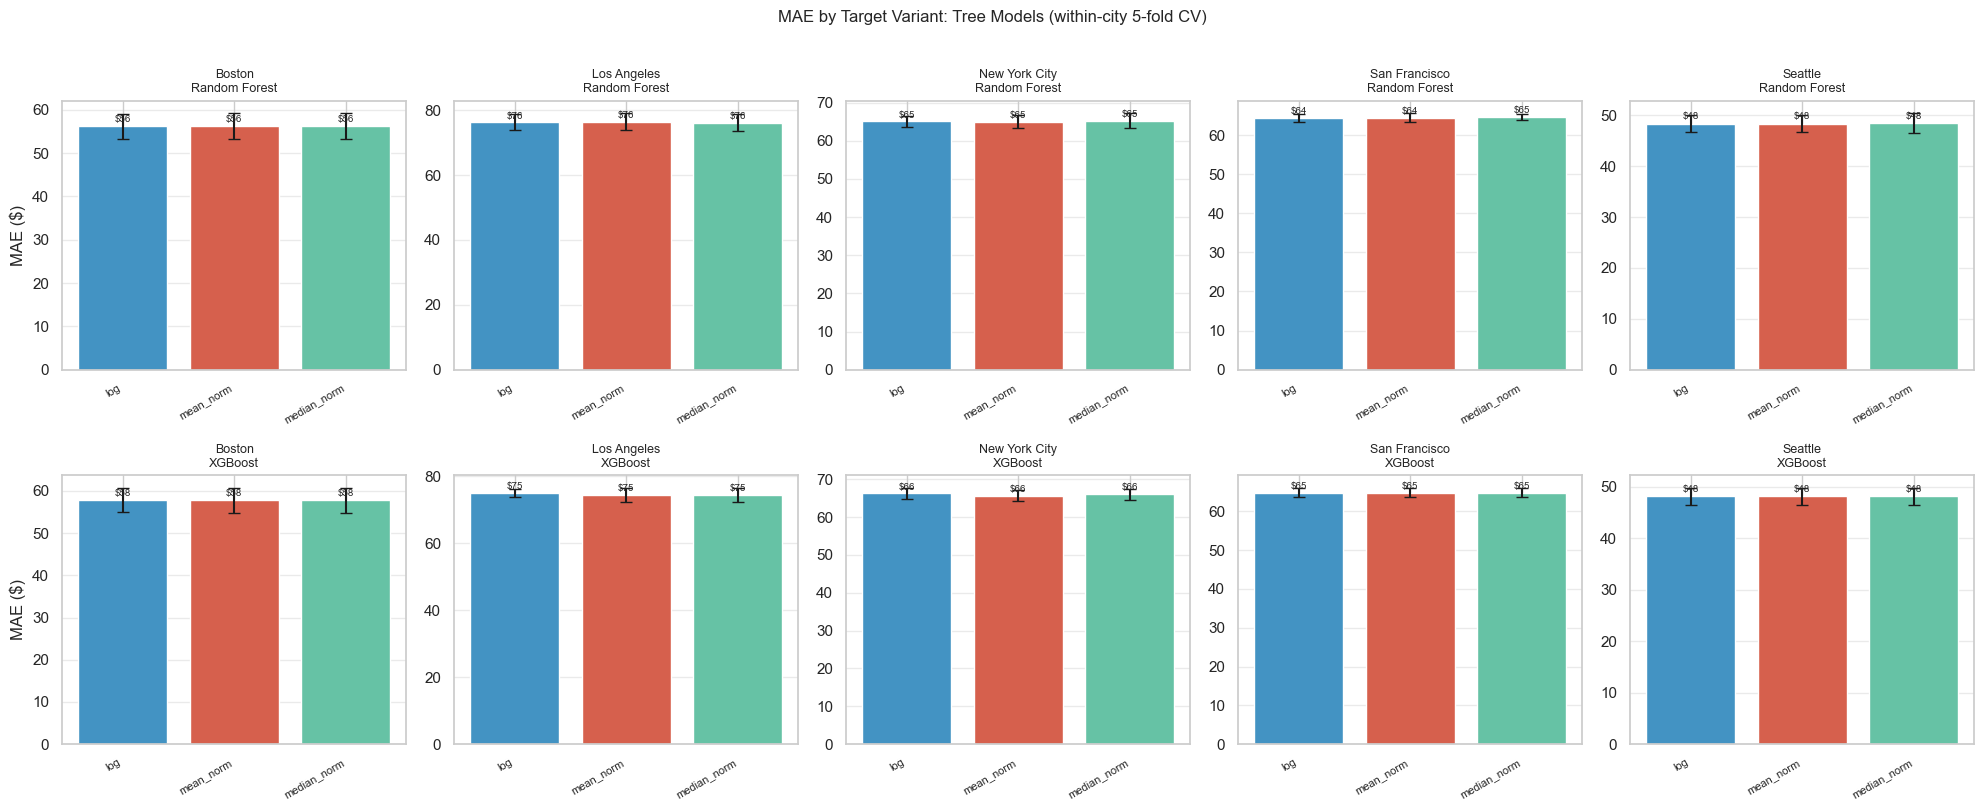

In [35]:
# Compare the three target variants for RF and XGB within each city
variant_palette = {
    "log_price":             "#4393c3",
    "mean_norm_log_price":   "#d6604d",
    "median_norm_log_price": "#66c2a5",
}

cities_sorted = sorted(model_ready["city"].unique())
fig, axes = plt.subplots(
    2, len(cities_sorted),
    figsize=(4 * len(cities_sorted), 8),
    sharey=False,
)

for col_i, city in enumerate(cities_sorted):
    for row_i, model_name in enumerate(["Random_Forest", "XGBoost"]):
        ax  = axes[row_i, col_i]
        sub = tree_summary[
            (tree_summary["Test_City"] == city) &
            (tree_summary["Model"]     == model_name)
        ].copy()
        bars = ax.bar(
            sub["Target_Variant"], sub["MAE_mean"],
            yerr=sub["MAE_std"], capsize=4,
            color=[variant_palette[v] for v in sub["Target_Variant"]],
            edgecolor="white",
        )
        ax.set_title(f"{city}\n{model_name.replace('_', ' ')}", fontsize=9)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(
            [v.replace("_log_price", "").replace("log_price", "log") for v in sub["Target_Variant"]],
            rotation=30, ha="right", fontsize=8,
        )
        ax.set_ylabel("MAE ($)" if col_i == 0 else "")
        ax.grid(axis="y", alpha=0.4)
        for bar, val in zip(bars, sub["MAE_mean"]):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5, f"${val:.0f}",
                    ha="center", va="bottom", fontsize=7)

plt.suptitle("MAE by Target Variant: Tree Models (within-city 5-fold CV)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_TREE}/tree_mae_by_target_variant.png", dpi=150, bbox_inches="tight")
plt.show()


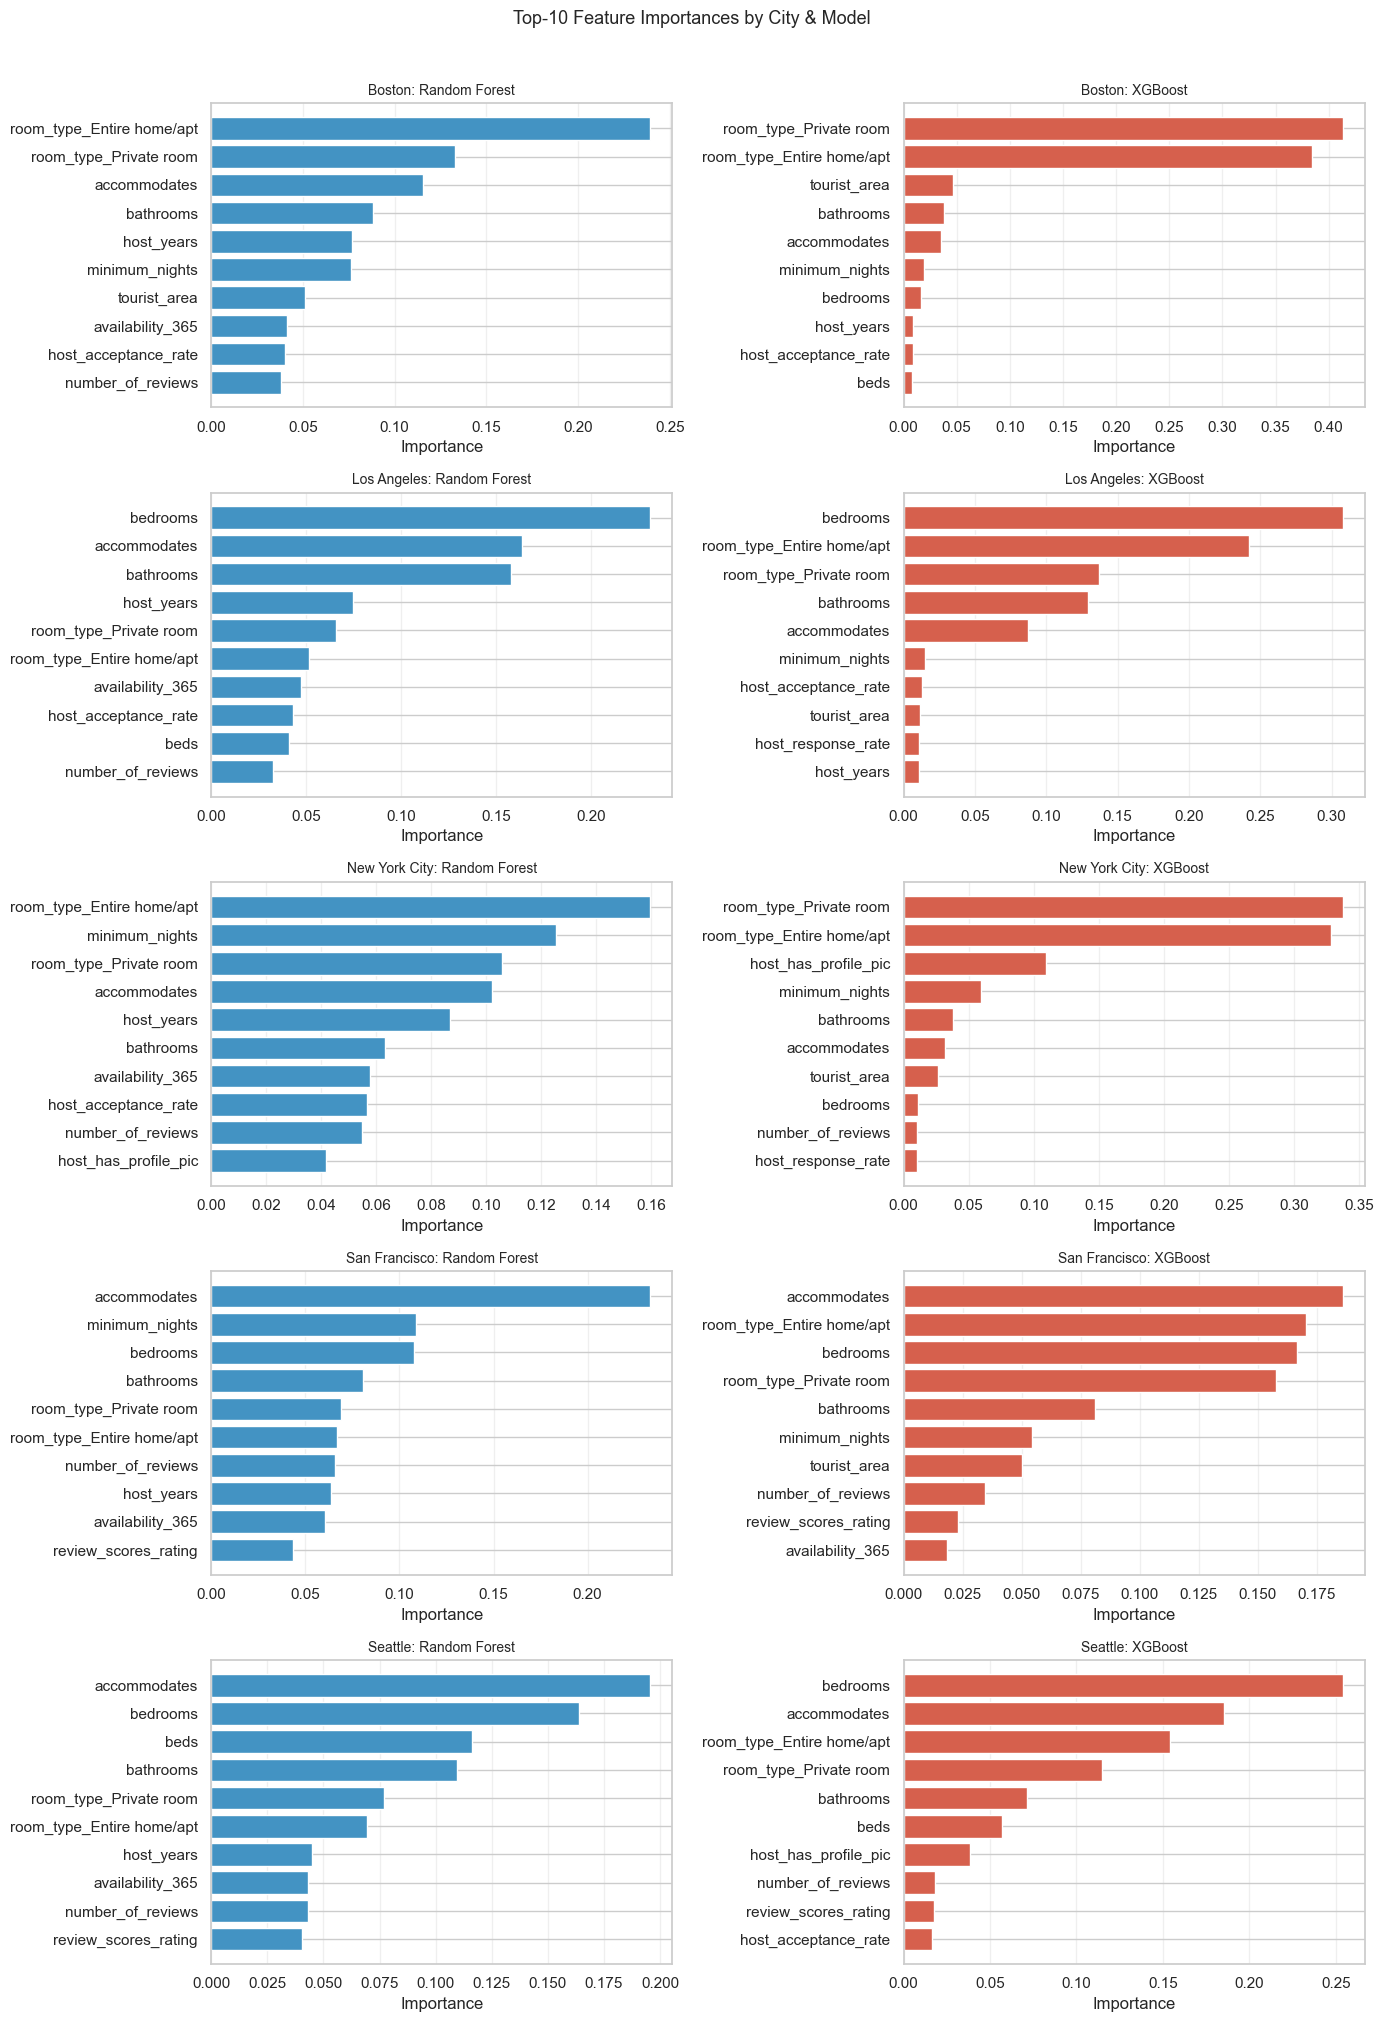

In [36]:
cities_sorted = sorted(model_ready["city"].unique())
fig, axes = plt.subplots(
    len(cities_sorted), 2,
    figsize=(14, 4 * len(cities_sorted)),
)

for row_i, city in enumerate(cities_sorted):
    for col_i, model_name in enumerate(["Random_Forest", "XGBoost"]):
        ax  = axes[row_i, col_i]
        sub = (
            feature_importance_df[
                (feature_importance_df["City"]  == city) &
                (feature_importance_df["Model"] == model_name)
            ]
            .sort_values("Importance", ascending=False)
            .head(10)
        )
        ax.barh(
            sub["Feature"].values[::-1],
            sub["Importance"].values[::-1],
            color="#4393c3" if model_name == "Random_Forest" else "#d6604d",
        )
        ax.set_title(f"{city}: {model_name.replace('_', ' ')}", fontsize=10)
        ax.set_xlabel("Importance")
        ax.grid(axis="x", alpha=0.3)

plt.suptitle("Top-10 Feature Importances by City & Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_TREE}/tree_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


,Test_City,Model,MAE_mean,RMSE_mean,R2_mean,Spearman_mean,Target_Variant
0,Boston,Mean_Baseline,126.786179,195.063222,-0.082188,NaN,n/a
1,Boston,Median_Baseline,126.402427,192.088075,-0.049523,NaN,n/a
2,Boston,Linear_Regression,80.348037,136.319790,0.469574,0.756517,n/a
3,Boston,Ridge,80.350024,136.329954,0.469499,0.756545,n/a
4,Boston,Lasso,80.354607,136.512720,0.468128,0.756356,n/a
5,Boston,Random_Forest,56.248547,106.972116,0.673490,0.896203,log_price
6,Boston,Random_Forest,56.190255,106.763931,0.674824,0.896035,mean_norm_log_price
7,Boston,Random_Forest,56.192140,106.783644,0.674706,0.895832,median_norm_log_price
8,Boston,XGBoost,57.845575,105.813653,0.679759,0.889729,log_price
9,Boston,XGBoost,57.775403,105.773319,0.680009,0.890044,mean_norm_log_price


Duplicate Model × Test_City combinations in full compare_df:


,Model,Test_City,count
34,XGBoost,Seattle,3
29,Random_Forest,Seattle,3
25,Random_Forest,Boston,3
26,Random_Forest,Los Angeles,3
28,Random_Forest,San Francisco,3
27,Random_Forest,New York City,3
30,XGBoost,Boston,3
31,XGBoost,Los Angeles,3
32,XGBoost,New York City,3
33,XGBoost,San Francisco,3


Duplicate Model × Test_City combinations used in heatmap:


,Model,Test_City,count


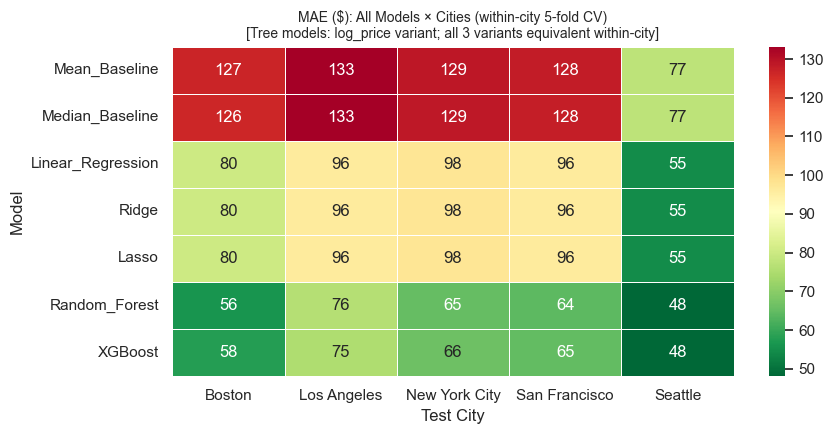

In [37]:
# Cross-model comparison: all baselines + tree models
# Table shows all 3 tree target variants.
# Heatmap uses only log_price variant for tree models to avoid duplicate Model × Test_City cells.
# Within-city all 3 tree variants should be numerically equivalent, so this is only for readability.

# Build comparison dataframe

baseline_compare = baseline_summary[[
    "Test_City", "Model", "MAE_mean", "RMSE_mean", "R2_mean", "Spearman_mean"
]].copy()

baseline_compare["Target_Variant"] = "n/a"

tree_compare = tree_summary[[
    "Test_City", "Model", "Target_Variant",
    "MAE_mean", "RMSE_mean", "R2_mean", "Spearman_mean"
]].copy()

compare_df = pd.concat([baseline_compare, tree_compare], ignore_index=True)

model_order_all = [
    "Mean_Baseline", "Median_Baseline",
    "Linear_Regression", "Ridge", "Lasso",
    "Random_Forest", "XGBoost",
]

compare_df["Model"] = pd.Categorical(
    compare_df["Model"],
    categories=model_order_all,
    ordered=True
)

compare_df = (
    compare_df
    .sort_values(["Test_City", "Model", "Target_Variant"])
    .reset_index(drop=True)
)

display(compare_df)

# Check duplicates in full table
# These duplicates are expected for tree models because they have 3 target variants.

dup_check = (
    compare_df
    .groupby(["Model", "Test_City"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Duplicate Model × Test_City combinations in full compare_df:")
display(dup_check[dup_check["count"] > 1])


# Heatmap dataframe
# Keep all baseline / linear models, but only log_price tree variant.

plot_df = compare_df[
    (compare_df["Target_Variant"] == "n/a") |
    (compare_df["Target_Variant"] == "log_price")
].copy()

plot_df = (
    plot_df
    .sort_values(["Test_City", "Model"])
    .reset_index(drop=True)
)

# Confirm no duplicates remain before pivot
dup_check_plot = (
    plot_df
    .groupby(["Model", "Test_City"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Duplicate Model × Test_City combinations used in heatmap:")
display(dup_check_plot[dup_check_plot["count"] > 1])


# MAE heatmap: all 7 models × 5 cities

mae_pivot = plot_df.pivot(
    index="Model",
    columns="Test_City",
    values="MAE_mean"
)

# Keep row order clean
mae_pivot = mae_pivot.reindex(model_order_all)

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.heatmap(
    mae_pivot,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "MAE ($): All Models × Cities (within-city 5-fold CV)\n"
    "[Tree models: log_price variant; all 3 variants equivalent within-city]",
    fontsize=10
)

ax.set_xlabel("Test City")
ax.set_ylabel("Model")

plt.tight_layout()

plt.savefig(
    f"{RESULTS_DIR_TREE}/all_models_mae_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Test

use the trained model based on one city to test on all other four cites

goal: see test performance as well as get insights about grouping  

In [38]:
# For each (train_city, target_variant, model) saved in Step 2,
# run inference on every OTHER city's full dataset.
RESULTS_DIR_TRANSFER = "results/tree"
os.makedirs(RESULTS_DIR_TRANSFER, exist_ok=True)

cities_all = sorted(model_ready["city"].unique())
transfer_results = []

In [39]:
for train_city in cities_all:
    for target_variant in TARGET_VARIANTS:
        for model_name in ["Random_Forest", "XGBoost"]:
            file_name = (
                f"tree__train-{clean_name(train_city)}"
                f"__variant-{clean_name(target_variant)}"
                f"__model-{clean_name(model_name)}.joblib"
            )
            bundle = joblib.load(f"{MODEL_DIR_TREE}/{file_name}")
            pipe         = bundle["pipe"]
            anchor_mean  = bundle["anchor_mean"]
            anchor_median= bundle["anchor_median"]

            test_cities = [c for c in cities_all if c != train_city]
            for test_city in test_cities:
                test_df    = model_ready[model_ready["city"] == test_city].copy()
                X_test     = test_df[feature_cols]
                y_log_test = test_df["log_price"].values

                y_pred_v = pipe.predict(X_test)
                if target_variant == "log_price":
                    y_pred_log = y_pred_v
                elif target_variant == "mean_norm_log_price":
                    y_pred_log = y_pred_v + np.log1p(anchor_mean)
                elif target_variant == "median_norm_log_price":
                    y_pred_log = y_pred_v + np.log1p(anchor_median)

                m = metrics_on_price(y_log_test, y_pred_log)
                transfer_results.append({
                    "Experiment":     "tree_cross_city_transfer",
                    "Target_Variant": target_variant,
                    "Train_City":     train_city,
                    "Test_City":      test_city,
                    "Model":          model_name,
                    "N_test":         len(X_test),
                    "Anchor_Mean":    anchor_mean,
                    "Anchor_Median":  anchor_median,
                    **m
                })
    print(f"  {train_city} → all other cities done")

transfer_results_df = pd.DataFrame(transfer_results)
display(transfer_results_df.head(10))

  Boston → all other cities done
  Los Angeles → all other cities done
  New York City → all other cities done
  San Francisco → all other cities done
  Seattle → all other cities done


,Experiment,Target_Variant,Train_City,Test_City,Model,N_test,Anchor_Mean,Anchor_Median,MAE,RMSE,Median_AE,R2,Spearman,Mean_Error,Overprice_Rate,Underprice_Rate,Within_25pct_Error,Within_50pct_Error
0,tree_cross_city_transfer,log_price,Boston,Los Angeles,Random_Forest,35817,244.040834,202.0,108.261694,183.175140,69.282532,0.429509,0.758556,13.147082,0.717453,0.282547,0.299746,0.549292
1,tree_cross_city_transfer,log_price,Boston,New York City,Random_Forest,20675,244.040834,202.0,98.641491,183.026306,45.668052,0.247531,0.692216,-55.504364,0.464474,0.535526,0.380895,0.684208
2,tree_cross_city_transfer,log_price,Boston,San Francisco,Random_Forest,5650,244.040834,202.0,92.013968,157.770873,55.883263,0.430785,0.707456,-24.497075,0.542832,0.457168,0.382832,0.710088
3,tree_cross_city_transfer,log_price,Boston,Seattle,Random_Forest,6137,244.040834,202.0,89.037653,131.518233,66.807778,0.079083,0.703729,57.177334,0.819945,0.180055,0.289881,0.534137
4,tree_cross_city_transfer,log_price,Boston,Los Angeles,XGBoost,35817,244.040834,202.0,109.086988,182.908435,68.489090,0.431169,0.756861,16.719819,0.715750,0.284250,0.301393,0.553564
5,tree_cross_city_transfer,log_price,Boston,New York City,XGBoost,20675,244.040834,202.0,98.189685,182.157263,44.958481,0.254659,0.712600,-58.129306,0.448416,0.551584,0.385296,0.692044
6,tree_cross_city_transfer,log_price,Boston,San Francisco,XGBoost,5650,244.040834,202.0,88.674462,150.841760,55.497456,0.479686,0.741313,-20.542131,0.558761,0.441239,0.380531,0.719823
7,tree_cross_city_transfer,log_price,Boston,Seattle,XGBoost,6137,244.040834,202.0,88.842619,131.668311,65.405594,0.076980,0.715345,57.900696,0.817663,0.182337,0.290696,0.539189
8,tree_cross_city_transfer,mean_norm_log_price,Boston,Los Angeles,Random_Forest,35817,244.040834,202.0,108.480701,183.367887,69.522609,0.428308,0.757887,13.532188,0.718681,0.281319,0.298517,0.549208
9,tree_cross_city_transfer,mean_norm_log_price,Boston,New York City,Random_Forest,20675,244.040834,202.0,98.508138,182.668769,45.567667,0.250468,0.694464,-55.233868,0.463748,0.536252,0.381233,0.685562


In [40]:
print(f"\nTotal transfer results: {len(transfer_results_df)} (expected 120)")

transfer_summary = transfer_results_df[[
    "Experiment", "Target_Variant", "Train_City", "Test_City", "Model",
    "N_test",
    "MAE", "RMSE", "Median_AE", "R2", "Spearman",
    "Mean_Error", "Overprice_Rate", "Underprice_Rate",
    "Within_25pct_Error", "Within_50pct_Error",
]].copy()

transfer_summary = transfer_summary.rename(columns={
    "MAE":                 "MAE_mean",
    "RMSE":                "RMSE_mean",
    "Median_AE":           "Median_AE_mean",
    "R2":                  "R2_mean",
    "Spearman":            "Spearman_mean",
    "Mean_Error":          "Mean_Error_mean",
    "Overprice_Rate":      "Overprice_Rate_mean",
    "Underprice_Rate":     "Underprice_Rate_mean",
    "Within_25pct_Error":  "Within_25pct_Error_mean",
    "Within_50pct_Error":  "Within_50pct_Error_mean",
})

display(
    transfer_summary
    .sort_values(["Target_Variant", "Train_City", "Test_City", "Model"])
    .reset_index(drop=True)
)


Total transfer results: 120 (expected 120)


,Experiment,Target_Variant,Train_City,Test_City,Model,N_test,MAE_mean,RMSE_mean,Median_AE_mean,R2_mean,Spearman_mean,Mean_Error_mean,Overprice_Rate_mean,Underprice_Rate_mean,Within_25pct_Error_mean,Within_50pct_Error_mean
0,tree_cross_city_transfer,log_price,Boston,Los Angeles,Random_Forest,35817,108.261694,183.175140,69.282532,0.429509,0.758556,13.147082,0.717453,0.282547,0.299746,0.549292
1,tree_cross_city_transfer,log_price,Boston,Los Angeles,XGBoost,35817,109.086988,182.908435,68.489090,0.431169,0.756861,16.719819,0.715750,0.284250,0.301393,0.553564
2,tree_cross_city_transfer,log_price,Boston,New York City,Random_Forest,20675,98.641491,183.026306,45.668052,0.247531,0.692216,-55.504364,0.464474,0.535526,0.380895,0.684208
3,tree_cross_city_transfer,log_price,Boston,New York City,XGBoost,20675,98.189685,182.157263,44.958481,0.254659,0.712600,-58.129306,0.448416,0.551584,0.385296,0.692044
4,tree_cross_city_transfer,log_price,Boston,San Francisco,Random_Forest,5650,92.013968,157.770873,55.883263,0.430785,0.707456,-24.497075,0.542832,0.457168,0.382832,0.710088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,tree_cross_city_transfer,median_norm_log_price,Seattle,Los Angeles,XGBoost,35817,90.525585,180.463160,40.621786,0.446277,0.775139,-44.284515,0.489600,0.510400,0.427227,0.741854
116,tree_cross_city_transfer,median_norm_log_price,Seattle,New York City,Random_Forest,20675,112.265494,206.524047,46.897449,0.041917,0.665497,-90.812314,0.337219,0.662781,0.331366,0.646530
117,tree_cross_city_transfer,median_norm_log_price,Seattle,New York City,XGBoost,20675,114.499477,208.252207,49.076765,0.025816,0.634825,-93.034238,0.313083,0.686917,0.326191,0.645901
118,tree_cross_city_transfer,median_norm_log_price,Seattle,San Francisco,Random_Forest,5650,106.408272,194.411469,45.477465,0.135696,0.723784,-91.500490,0.280885,0.719115,0.390088,0.718584


In [41]:
transfer_results_df.to_csv(
    f"{RESULTS_DIR_TRANSFER}/tree__cross_city_transfer__all_results.csv",
    index=False,
)
transfer_summary.to_csv(
    f"{RESULTS_DIR_TRANSFER}/tree__cross_city_transfer__summary.csv",
    index=False,
)
with pd.ExcelWriter(
    f"{RESULTS_DIR_TRANSFER}/tree__cross_city_transfer__performance.xlsx"
) as writer:
    transfer_results_df.to_excel(writer, sheet_name="all_results", index=False)
    transfer_summary.to_excel(writer, sheet_name="summary",     index=False)

print("Transfer results saved.")

Transfer results saved.


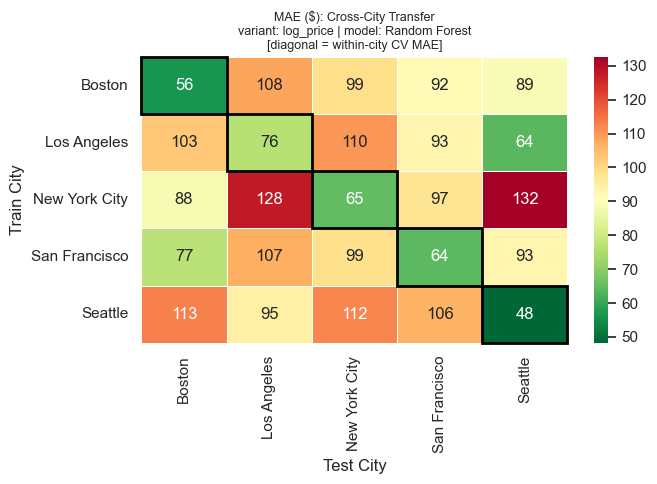

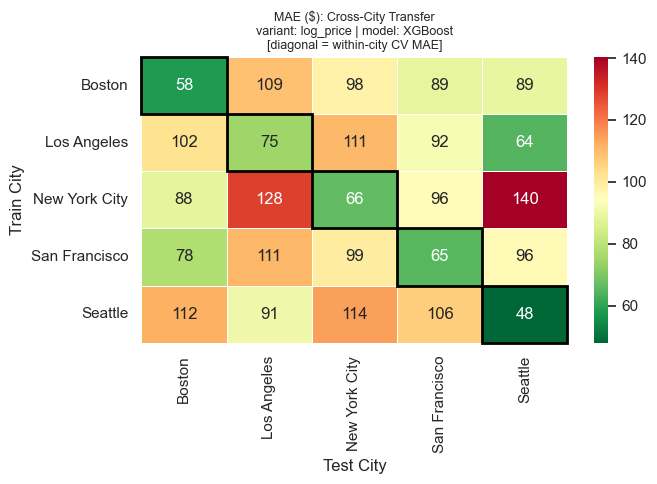

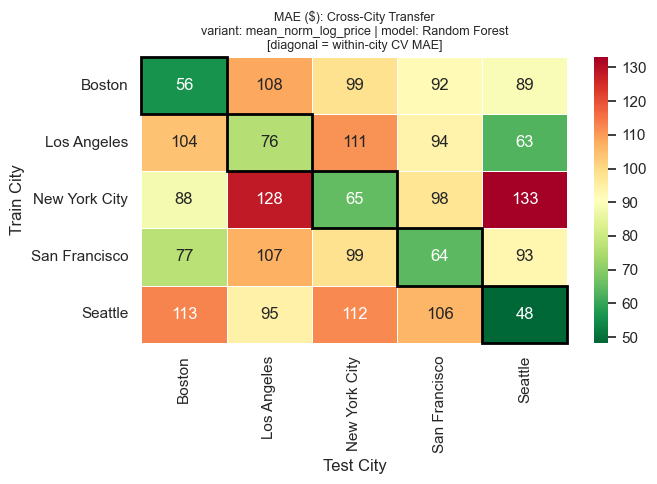

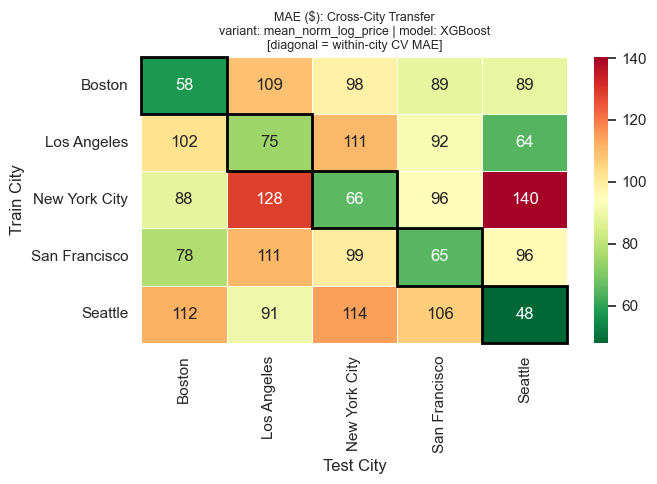

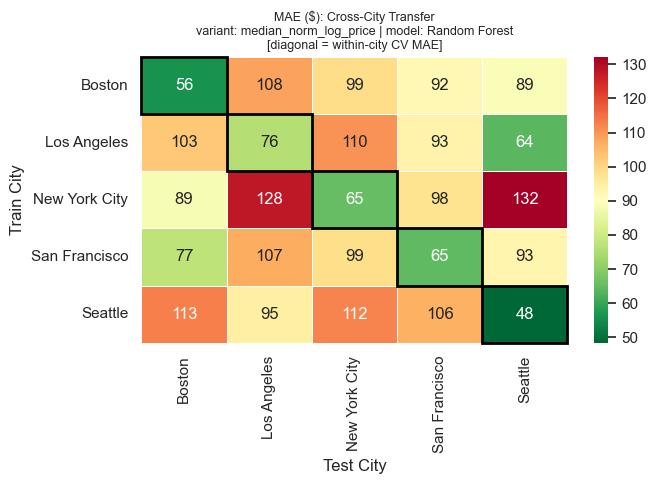

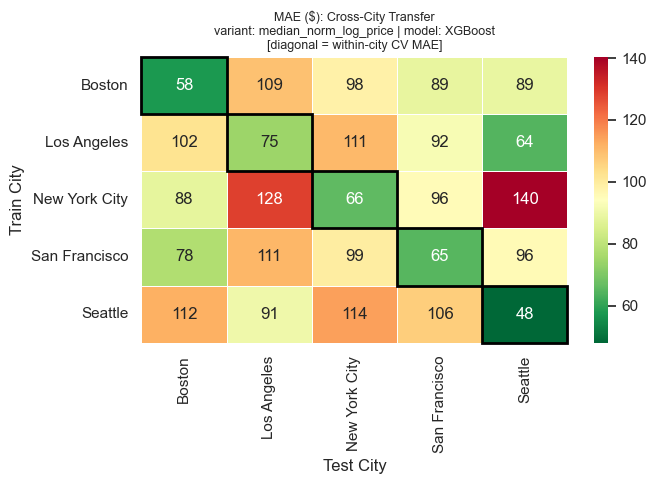

In [42]:
within_city_mae = (
    tree_summary[tree_summary["Train_City"] == tree_summary["Test_City"]]
    [["Target_Variant", "Train_City", "Model", "MAE_mean"]]
    .rename(columns={"Train_City": "City"})
)

for target_variant in TARGET_VARIANTS:
    for model_name in ["Random_Forest", "XGBoost"]:
        cross_slice = transfer_summary[
            (transfer_summary["Target_Variant"] == target_variant) &
            (transfer_summary["Model"] == model_name)
        ][["Train_City", "Test_City", "MAE_mean"]].copy()

        within_slice = within_city_mae[
            (within_city_mae["Target_Variant"] == target_variant) &
            (within_city_mae["Model"] == model_name)
        ][["City", "MAE_mean"]].copy()
        within_slice["Train_City"] = within_slice["City"]
        within_slice["Test_City"]  = within_slice["City"]
        within_slice = within_slice[["Train_City", "Test_City", "MAE_mean"]]

        full_matrix = pd.concat([cross_slice, within_slice], ignore_index=True)
        mae_matrix  = full_matrix.pivot(
            index="Train_City", columns="Test_City", values="MAE_mean"
        ).reindex(index=cities_all, columns=cities_all)

        fig, ax = plt.subplots(figsize=(7, 5))
        sns.heatmap(mae_matrix, annot=True, fmt=".0f",
                    cmap="RdYlGn_r", linewidths=0.5, ax=ax)

        for i in range(len(cities_all)):          # box the diagonal
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1, fill=False, edgecolor="black", lw=2, clip_on=False
            ))

        ax.set_title(
            f"MAE ($): Cross-City Transfer\n"
            f"variant: {target_variant} | model: {model_name.replace('_',' ')}\n"
            f"[diagonal = within-city CV MAE]",
            fontsize=9,
        )
        ax.set_xlabel("Test City")
        ax.set_ylabel("Train City")
        plt.tight_layout()
        plt.savefig(
            f"{RESULTS_DIR_TRANSFER}/tree_cross_city_mae_heatmap"
            f"__{clean_name(target_variant)}__{clean_name(model_name)}.png",
            dpi=150, bbox_inches="tight",
        )
        plt.show()

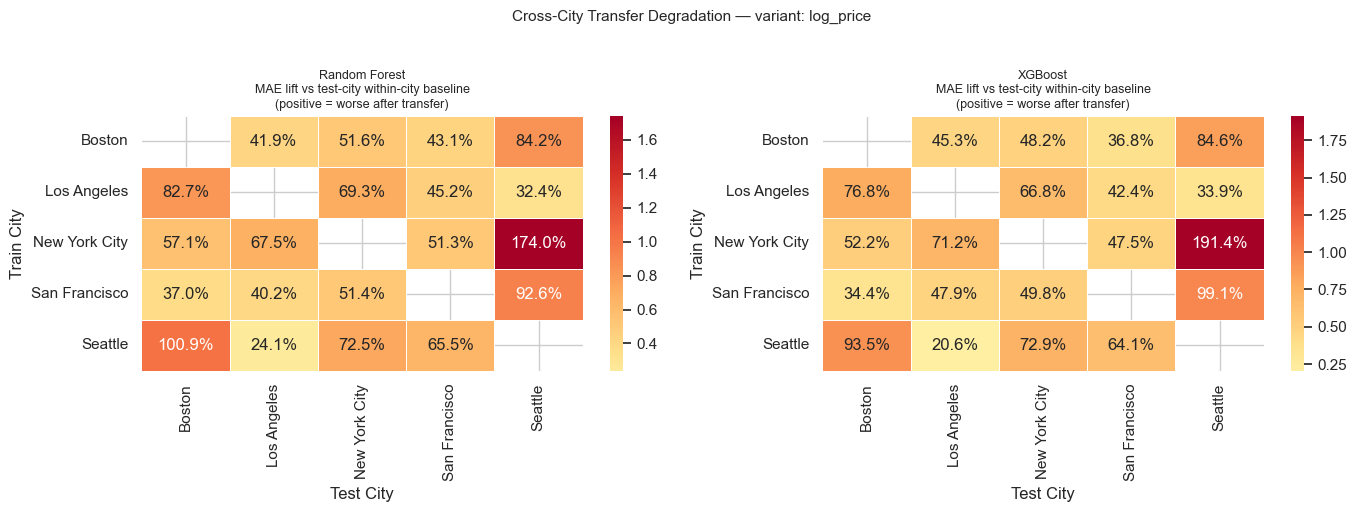

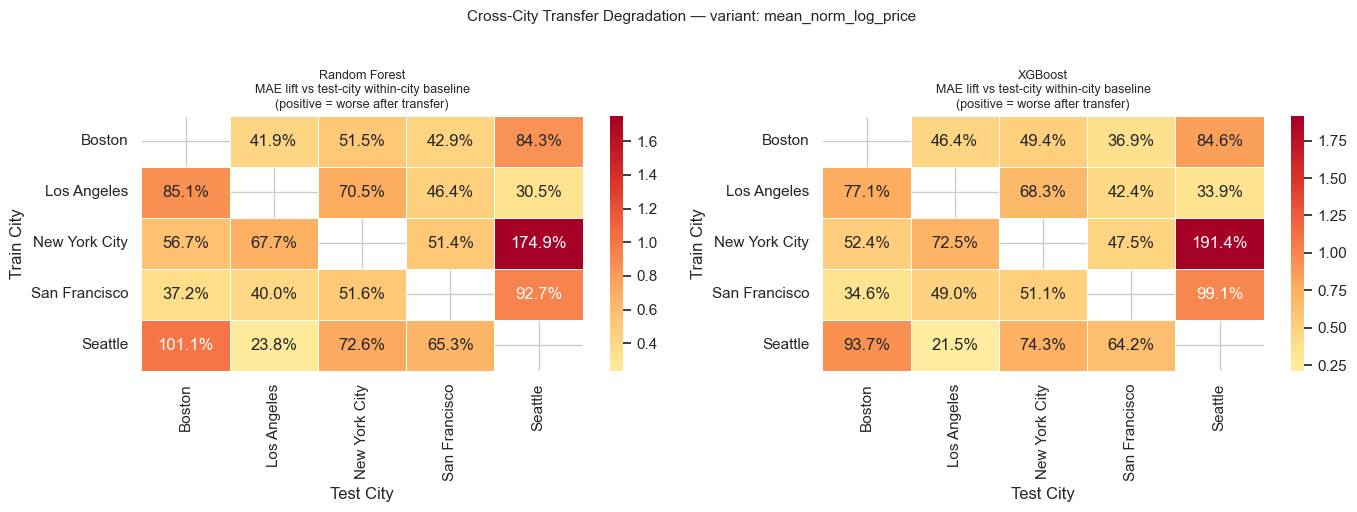

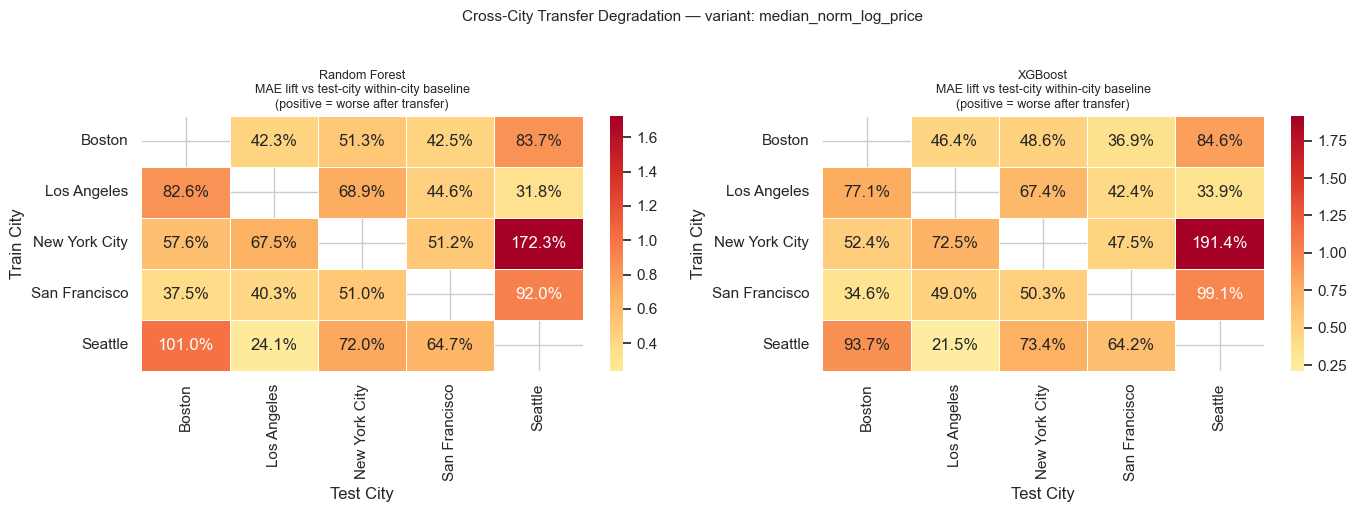


City-pair transfer quality (log_price, averaged across RF & XGB)
Lower MAE_Degradation = better transfer (cities more compatible)



,Train_City,Test_City,MAE_mean,MAE_Degradation,Within_25pct_Error_mean
17,Seattle,Los Angeles,92.584,0.223,0.423
7,Los Angeles,Seattle,64.231,0.332,0.448
12,San Francisco,Boston,77.404,0.357,0.496
2,Boston,San Francisco,90.344,0.399,0.382
0,Boston,Los Angeles,108.674,0.436,0.301
6,Los Angeles,San Francisco,92.834,0.438,0.449
13,San Francisco,Los Angeles,108.988,0.441,0.323
10,New York City,San Francisco,96.454,0.494,0.349
1,Boston,New York City,98.416,0.499,0.383
14,San Francisco,New York City,98.870,0.506,0.391


Grouping signal table saved.


In [43]:
# degradation heatmaps (3 plots: one per variant)
for target_variant in TARGET_VARIANTS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, model_name in zip(axes, ["Random_Forest", "XGBoost"]):
        cross_slice = transfer_summary[
            (transfer_summary["Target_Variant"] == target_variant) &
            (transfer_summary["Model"] == model_name)
        ][["Train_City", "Test_City", "MAE_mean"]].copy()

        within_ref = within_city_mae[
            (within_city_mae["Target_Variant"] == target_variant) &
            (within_city_mae["Model"] == model_name)
        ].set_index("City")["MAE_mean"].to_dict()

        cross_slice["Within_MAE"]  = cross_slice["Test_City"].map(within_ref)
        cross_slice["Degradation"] = (
            (cross_slice["MAE_mean"] - cross_slice["Within_MAE"])
            / cross_slice["Within_MAE"]
        )
        deg_matrix = cross_slice.pivot(
            index="Train_City", columns="Test_City", values="Degradation"
        ).reindex(index=cities_all, columns=cities_all)

        sns.heatmap(deg_matrix, annot=True, fmt=".1%",
                    cmap="RdYlGn_r", center=0, linewidths=0.5, ax=ax)
        ax.set_title(
            f"{model_name.replace('_',' ')}\n"
            f"MAE lift vs test-city within-city baseline\n"
            f"(positive = worse after transfer)", fontsize=9,
        )
        ax.set_xlabel("Test City")
        ax.set_ylabel("Train City")

    fig.suptitle(
        f"Cross-City Transfer Degradation — variant: {target_variant}",
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(
        f"{RESULTS_DIR_TRANSFER}/tree__cross_city_degradation"
        f"__{clean_name(target_variant)}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

# grouping signal table
grouping_df = transfer_summary[
    transfer_summary["Target_Variant"] == "log_price"
][["Train_City", "Test_City", "Model",
   "MAE_mean", "R2_mean", "Within_25pct_Error_mean"]].copy()

within_ref_lp = within_city_mae[
    within_city_mae["Target_Variant"] == "log_price"
].set_index(["City", "Model"])["MAE_mean"].to_dict()

grouping_df["Within_MAE"] = grouping_df.apply(
    lambda r: within_ref_lp.get((r["Test_City"], r["Model"]), np.nan), axis=1
)
grouping_df["MAE_Degradation"] = (
    (grouping_df["MAE_mean"] - grouping_df["Within_MAE"])
    / grouping_df["Within_MAE"]
)

grouping_avg = (
    grouping_df
    .groupby(["Train_City", "Test_City"])
    [["MAE_mean", "MAE_Degradation", "Within_25pct_Error_mean"]]
    .mean()
    .round(3)
    .reset_index()
    .sort_values("MAE_Degradation")
)

print("\nCity-pair transfer quality (log_price, averaged across RF & XGB)")
print("Lower MAE_Degradation = better transfer (cities more compatible)\n")
display(grouping_avg)

grouping_avg.to_csv(
    f"{RESULTS_DIR_TRANSFER}/tree__cross_city_grouping_signal.csv",
    index=False,
)
print("Grouping signal table saved.")

### Test2

feature-transfer after target-city calibration

In [44]:
# Test2 — Feature-Transfer after Target-City Calibration
# Key difference vs Test (strict OOD):
#   Test (strict): pipe.predict(X_test) uses train-city scaler AS-IS.
#                  Denorm adds back TRAIN-city anchor.

#   Test2 (calibrated): re-center each numeric feature of X_test
#                       so its per-feature mean matches the train
#                       scaler's fitted mean — i.e. shift features
#                       by (test_feat_mean - train_feat_mean) before
#                       the scaler sees them.  This isolates pure
#                       feature-relationship transfer from price-level
#                       mismatch.  Denorm then adds back TEST-city
#                       price anchor (mean or median).

# Concretely for LA-trained model tested on Seattle:
#   1. Extract train scaler means (mu_train) from the fitted pipeline.
#   2. Compute Seattle feature means (mu_test).
#   3. Shift X_seattle += (mu_train - mu_test)  [in raw feature space,
#      before the scaler touches it — equivalent to re-centering].
#   4. Run shifted X through the pipeline normally.
#   5. Denorm: add back log1p(seattle_anchor_mean or median).

RESULTS_DIR_CALIB = "results/tree"
os.makedirs(RESULTS_DIR_CALIB, exist_ok=True)

cities_all = sorted(model_ready["city"].unique())
calibrated_results = []

for train_city in cities_all:
    for target_variant in TARGET_VARIANTS:
        for model_name in ["Random_Forest", "XGBoost"]:

            # Load model trained on train_city

            file_name = (
                f"tree__train-{clean_name(train_city)}"
                f"__variant-{clean_name(target_variant)}"
                f"__model-{clean_name(model_name)}.joblib"
            )
            model_path = f"{MODEL_DIR_TREE}/{file_name}"

            if not os.path.exists(model_path):
                print(f"Missing model file: {model_path}")
                continue

            bundle = joblib.load(model_path)
            pipe = bundle["pipe"]
            train_anchor_mean   = bundle["anchor_mean"]
            train_anchor_median = bundle["anchor_median"]

            # Extract train-city per-feature means from the fitted scaler.
            # Pipeline layout: prep (ColumnTransformer) -> model
            #   prep sub-transformers: "num" (imputer -> scaler), "cat" (imputer -> onehot)
            num_transformer  = pipe.named_steps["prep"].named_transformers_["num"]
            train_feat_means = num_transformer.named_steps["scaler"].mean_
            # train_feat_means[i] = mean of numeric_features[i] in the train city,
            # as seen by the scaler (i.e. after median-imputation on train data).

            # Test on every OTHER city
            test_cities = [c for c in cities_all if c != train_city]

            for test_city in test_cities:

                test_df    = model_ready[model_ready["city"] == test_city].copy()
                y_log_test = test_df["log_price"].values

                # TEST-city price anchors for denormalization
                test_price         = test_df["price"].values
                test_anchor_mean   = test_price.mean()
                test_anchor_median = np.median(test_price)

                # Feature calibration: shift numeric features of
                # X_test so their column means match train_feat_means.
                #
                # This removes city-level feature-mean offset so the
                # model sees residuals from its own training mean,
                # not from the test city's raw mean.
                X_test_raw = test_df[feature_cols].copy()

                # Impute missing values with train-city imputer first
                num_imputer = num_transformer.named_steps["imputer"]
                X_numeric   = X_test_raw[numeric_features].copy()
                X_numeric_imputed = pd.DataFrame(
                    num_imputer.transform(X_numeric),
                    columns=numeric_features,
                    index=X_numeric.index,
                )

                # Per-feature mean of test city after imputation
                test_feat_means = X_numeric_imputed.mean().values   # shape (n_num_features,)

                # Shift: add (train_mean - test_mean) to each numeric feature
                shift = train_feat_means - test_feat_means          # shape (n_num_features,)
                X_test_shifted = X_test_raw.copy()
                X_test_shifted[numeric_features] = X_numeric_imputed.values + shift

                # Predict using calibrated shifted features
                y_pred_v = pipe.predict(X_test_shifted)

                # (denorm) add back TEST-city price anchor
                if target_variant == "log_price":
                    # No price anchor in training target, but still use
                    # test-city log-price mean shift for fair calibration.
                    # Compute: shift by (test_city mean log_price - train_city mean log_price)
                    train_log_mean = np.log1p(train_anchor_mean)
                    test_log_mean  = np.log1p(test_anchor_mean)
                    y_pred_log     = y_pred_v + (test_log_mean - train_log_mean)

                elif target_variant == "mean_norm_log_price":
                    # Model was trained on (log_price - log1p(train_mean))
                    # Add back TEST-city mean anchor
                    y_pred_log = y_pred_v + np.log1p(test_anchor_mean)

                elif target_variant == "median_norm_log_price":
                    # Model was trained on (log_price - log1p(train_median))
                    # Add back TEST-city median anchor
                    y_pred_log = y_pred_v + np.log1p(test_anchor_median)

                else:
                    raise ValueError(f"Unknown target_variant: {target_variant}")

                # Evaluate in raw price space
                m = metrics_on_price(y_log_test, y_pred_log)

                calibrated_results.append({
                    "Experiment":      "tree_cross_city_transfer_calibrated",
                    "Transfer_Mode":   "feature_calibrated_test_city_anchor",
                    "Target_Variant":  target_variant,
                    "Train_City":      train_city,
                    "Test_City":       test_city,
                    "Model":           model_name,
                    "N_test":          len(test_df),

                    # train-city anchors (for reference / comparison with Test)
                    "Train_Anchor_Mean":   train_anchor_mean,
                    "Train_Anchor_Median": train_anchor_median,

                    # test-city anchors used for denorm
                    "Test_Anchor_Mean":   test_anchor_mean,
                    "Test_Anchor_Median": test_anchor_median,

                    **m
                })

    print(f"{train_city} → all other cities calibrated-transfer done")

calibrated_results_df = pd.DataFrame(calibrated_results)

expected_n = len(cities_all) * (len(cities_all) - 1) * len(TARGET_VARIANTS) * 2
print(f"\nTotal calibrated transfer results: {len(calibrated_results_df)} expected: {expected_n}")
assert len(calibrated_results_df) == expected_n

display(calibrated_results_df.head(10))


Boston → all other cities calibrated-transfer done
Los Angeles → all other cities calibrated-transfer done
New York City → all other cities calibrated-transfer done
San Francisco → all other cities calibrated-transfer done
Seattle → all other cities calibrated-transfer done

Total calibrated transfer results: 120 expected: 120


,Experiment,Transfer_Mode,Target_Variant,Train_City,Test_City,Model,N_test,Train_Anchor_Mean,Train_Anchor_Median,Test_Anchor_Mean,Test_Anchor_Median,MAE,RMSE,Median_AE,R2,Spearman,Mean_Error,Overprice_Rate,Underprice_Rate,Within_25pct_Error,Within_50pct_Error
0,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,Los Angeles,Random_Forest,35817,244.040834,202.0,227.168021,154.0,95.734990,190.628148,45.131716,0.382141,0.753621,-42.601825,0.516654,0.483346,0.398638,0.710166
1,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,New York City,Random_Forest,20675,244.040834,202.0,219.501137,150.0,101.763634,189.759471,45.894777,0.191149,0.667855,-63.812694,0.455865,0.544135,0.369577,0.667134
2,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,San Francisco,Random_Forest,5650,244.040834,202.0,232.768142,169.0,90.600292,160.655562,49.498763,0.409780,0.714854,-37.690599,0.493805,0.506195,0.417345,0.722478
3,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,Seattle,Random_Forest,6137,244.040834,202.0,179.383738,148.0,58.879759,113.449977,33.360995,0.314736,0.698322,-22.576655,0.436533,0.563467,0.504155,0.829884
4,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,Los Angeles,XGBoost,35817,244.040834,202.0,227.168021,154.0,97.718845,199.484879,43.581512,0.323395,0.741651,-52.783578,0.485189,0.514811,0.407516,0.715387
5,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,New York City,XGBoost,20675,244.040834,202.0,219.501137,150.0,102.210155,192.882064,42.664577,0.164309,0.697180,-75.194729,0.379347,0.620653,0.395937,0.708392
6,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,San Francisco,XGBoost,5650,244.040834,202.0,232.768142,169.0,88.606998,159.939269,48.010844,0.415031,0.733277,-39.802543,0.512566,0.487434,0.425664,0.736991
7,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,Seattle,XGBoost,6137,244.040834,202.0,179.383738,148.0,61.045582,119.143268,34.198971,0.244233,0.667609,-40.060808,0.343001,0.656999,0.489001,0.841128
8,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,mean_norm_log_price,Boston,Los Angeles,Random_Forest,35817,244.040834,202.0,227.168021,154.0,95.775272,190.660468,45.116210,0.381931,0.754232,-42.662727,0.515928,0.484072,0.398498,0.709551
9,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,mean_norm_log_price,Boston,New York City,Random_Forest,20675,244.040834,202.0,219.501137,150.0,101.817208,189.840590,45.694961,0.190457,0.666854,-63.784271,0.456010,0.543990,0.368222,0.666796


In [45]:
# Summary table

calibrated_summary = calibrated_results_df[[
    "Experiment", "Transfer_Mode", "Target_Variant",
    "Train_City", "Test_City", "Model", "N_test",
    "Train_Anchor_Mean", "Train_Anchor_Median",
    "Test_Anchor_Mean", "Test_Anchor_Median",
    "MAE", "RMSE", "Median_AE", "R2", "Spearman",
    "Mean_Error", "Overprice_Rate", "Underprice_Rate",
    "Within_25pct_Error", "Within_50pct_Error",
]].copy()

calibrated_summary = calibrated_summary.rename(columns={
    "MAE": "MAE_mean",
    "RMSE": "RMSE_mean",
    "Median_AE": "Median_AE_mean",
    "R2": "R2_mean",
    "Spearman": "Spearman_mean",
    "Mean_Error": "Mean_Error_mean",
    "Overprice_Rate": "Overprice_Rate_mean",
    "Underprice_Rate": "Underprice_Rate_mean",
    "Within_25pct_Error": "Within_25pct_Error_mean",
    "Within_50pct_Error": "Within_50pct_Error_mean",
})

display(
    calibrated_summary
    .sort_values(["Target_Variant", "Train_City", "Test_City", "Model"])
    .reset_index(drop=True)
)

# save
calibrated_results_df.to_csv(
    f"{RESULTS_DIR_CALIB}/tree__cross_city_transfer_calibrated__all_results.csv",
    index=False,
)

calibrated_summary.to_csv(
    f"{RESULTS_DIR_CALIB}/tree__cross_city_transfer_calibrated__summary.csv",
    index=False,
)

with pd.ExcelWriter(
    f"{RESULTS_DIR_CALIB}/tree__cross_city_transfer_calibrated__performance.xlsx"
) as writer:
    calibrated_results_df.to_excel(writer, sheet_name="all_results", index=False)
    calibrated_summary.to_excel(writer, sheet_name="summary", index=False)

print("Calibrated transfer results saved.")

,Experiment,Transfer_Mode,Target_Variant,Train_City,Test_City,Model,N_test,Train_Anchor_Mean,Train_Anchor_Median,Test_Anchor_Mean,Test_Anchor_Median,MAE_mean,RMSE_mean,Median_AE_mean,R2_mean,Spearman_mean,Mean_Error_mean,Overprice_Rate_mean,Underprice_Rate_mean,Within_25pct_Error_mean,Within_50pct_Error_mean
0,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,Los Angeles,Random_Forest,35817,244.040834,202.0,227.168021,154.0,95.734990,190.628148,45.131716,0.382141,0.753621,-42.601825,0.516654,0.483346,0.398638,0.710166
1,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,Los Angeles,XGBoost,35817,244.040834,202.0,227.168021,154.0,97.718845,199.484879,43.581512,0.323395,0.741651,-52.783578,0.485189,0.514811,0.407516,0.715387
2,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,New York City,Random_Forest,20675,244.040834,202.0,219.501137,150.0,101.763634,189.759471,45.894777,0.191149,0.667855,-63.812694,0.455865,0.544135,0.369577,0.667134
3,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,New York City,XGBoost,20675,244.040834,202.0,219.501137,150.0,102.210155,192.882064,42.664577,0.164309,0.697180,-75.194729,0.379347,0.620653,0.395937,0.708392
4,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,log_price,Boston,San Francisco,Random_Forest,5650,244.040834,202.0,232.768142,169.0,90.600292,160.655562,49.498763,0.409780,0.714854,-37.690599,0.493805,0.506195,0.417345,0.722478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,median_norm_log_price,Seattle,Los Angeles,XGBoost,35817,179.383738,148.0,227.168021,154.0,110.043007,214.292995,48.236207,0.219215,0.729626,-97.379165,0.227127,0.772873,0.339532,0.693805
116,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,median_norm_log_price,Seattle,New York City,Random_Forest,20675,179.383738,148.0,219.501137,150.0,109.129380,202.138758,48.968587,0.082173,0.619628,-71.027678,0.460508,0.539492,0.336735,0.616106
117,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,median_norm_log_price,Seattle,New York City,XGBoost,20675,179.383738,148.0,219.501137,150.0,116.973161,211.755898,50.830503,-0.007240,0.513943,-87.541285,0.370060,0.629940,0.312213,0.614123
118,tree_cross_city_transfer_calibrated,feature_calibrated_test_city_anchor,median_norm_log_price,Seattle,San Francisco,Random_Forest,5650,179.383738,148.0,232.768142,169.0,101.192422,185.626411,47.044644,0.212043,0.696620,-70.456759,0.420885,0.579115,0.379469,0.699646


Calibrated transfer results saved.


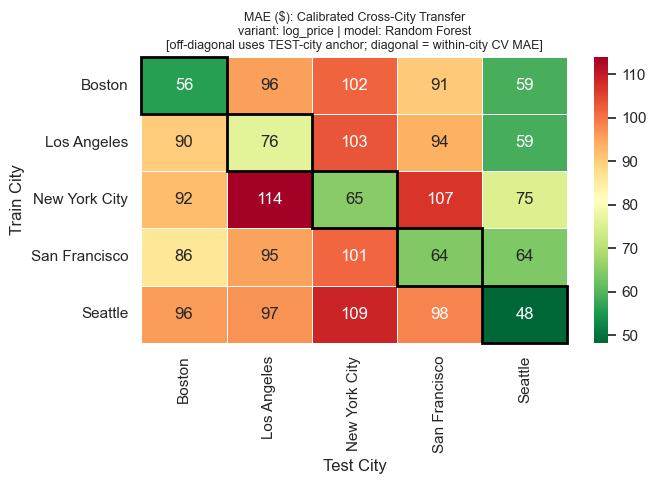

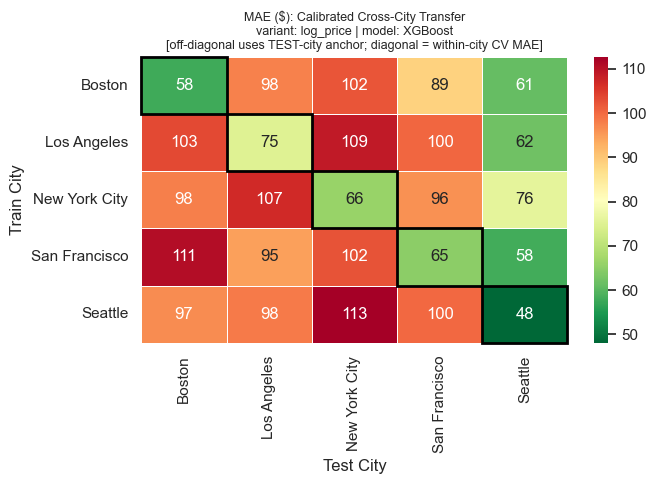

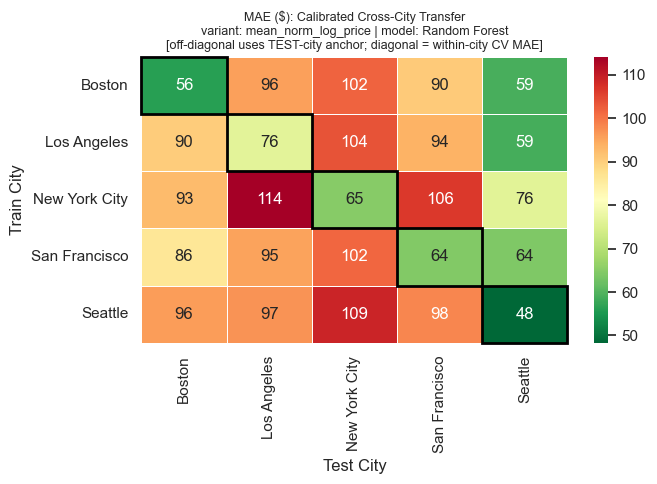

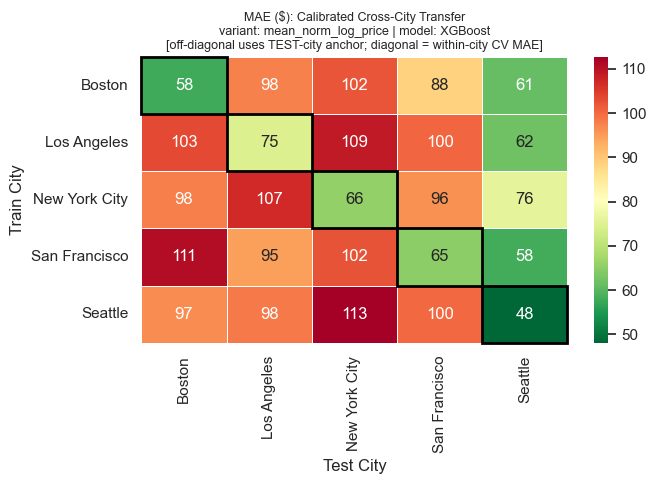

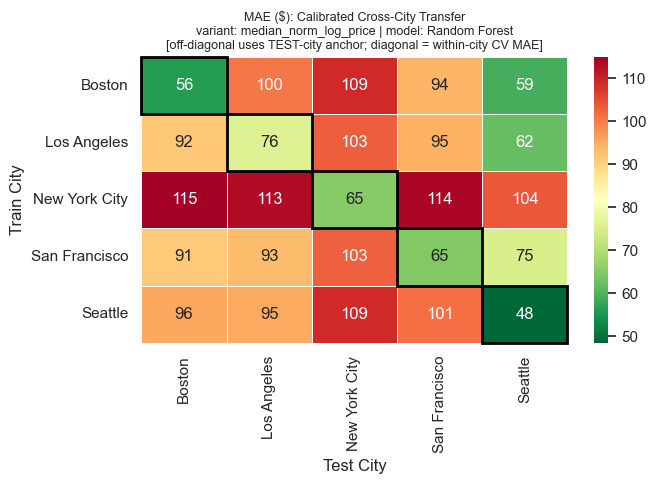

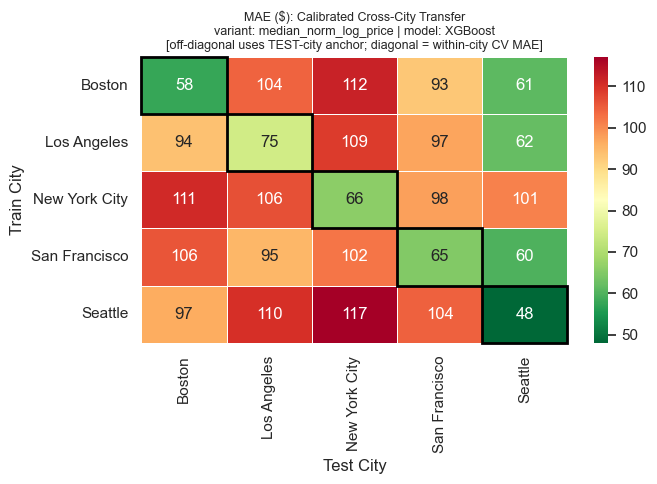

In [46]:
# Calibrated MAE heatmaps
# rows = train city
# cols = test city
# diagonal = within-city CV MAE

within_city_mae = (
    tree_summary[tree_summary["Train_City"] == tree_summary["Test_City"]]
    [["Target_Variant", "Train_City", "Model", "MAE_mean"]]
    .rename(columns={"Train_City": "City"})
)

for target_variant in TARGET_VARIANTS:
    for model_name in ["Random_Forest", "XGBoost"]:

        cross_slice = calibrated_summary[
            (calibrated_summary["Target_Variant"] == target_variant) &
            (calibrated_summary["Model"] == model_name)
        ][["Train_City", "Test_City", "MAE_mean"]].copy()

        within_slice = within_city_mae[
            (within_city_mae["Target_Variant"] == target_variant) &
            (within_city_mae["Model"] == model_name)
        ][["City", "MAE_mean"]].copy()

        within_slice["Train_City"] = within_slice["City"]
        within_slice["Test_City"] = within_slice["City"]
        within_slice = within_slice[["Train_City", "Test_City", "MAE_mean"]]

        full_matrix = pd.concat([cross_slice, within_slice], ignore_index=True)

        mae_matrix = full_matrix.pivot(
            index="Train_City",
            columns="Test_City",
            values="MAE_mean"
        ).reindex(index=cities_all, columns=cities_all)

        fig, ax = plt.subplots(figsize=(7, 5))

        sns.heatmap(
            mae_matrix,
            annot=True,
            fmt=".0f",
            cmap="RdYlGn_r",
            linewidths=0.5,
            ax=ax,
        )

        # box diagonal
        for i in range(len(cities_all)):
            ax.add_patch(
                plt.Rectangle(
                    (i, i), 1, 1,
                    fill=False,
                    edgecolor="black",
                    lw=2,
                    clip_on=False,
                )
            )

        ax.set_title(
            f"MAE ($): Calibrated Cross-City Transfer\n"
            f"variant: {target_variant} | model: {model_name.replace('_', ' ')}\n"
            f"[off-diagonal uses TEST-city anchor; diagonal = within-city CV MAE]",
            fontsize=9,
        )
        ax.set_xlabel("Test City")
        ax.set_ylabel("Train City")

        plt.tight_layout()
        plt.savefig(
            f"{RESULTS_DIR_CALIB}/tree__cross_city_calibrated_mae_heatmap"
            f"__{clean_name(target_variant)}__{clean_name(model_name)}.png",
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()

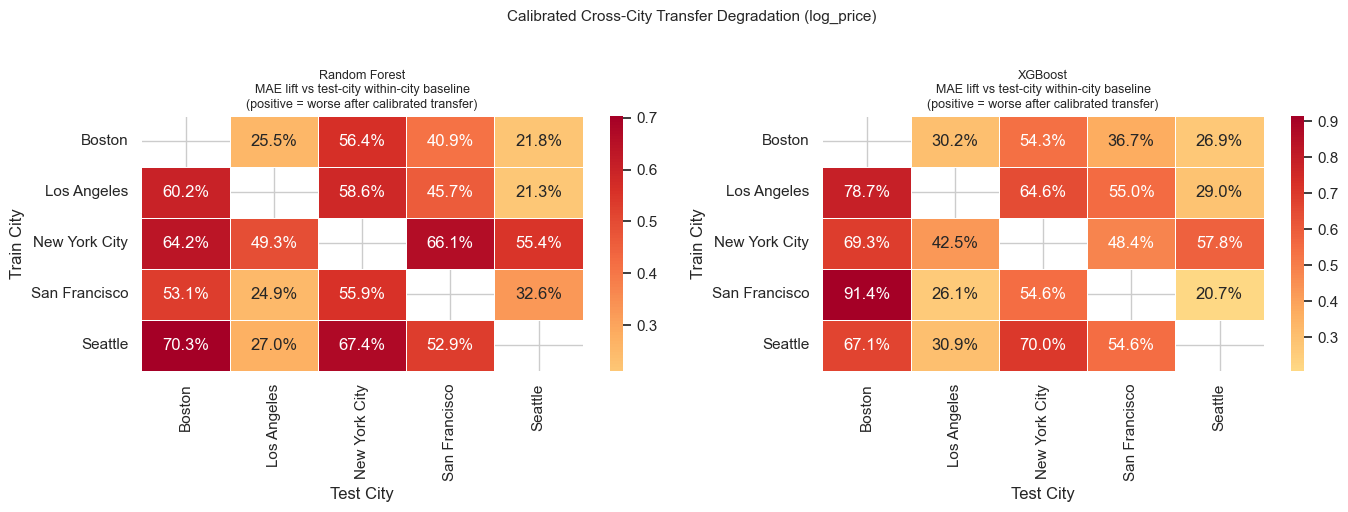

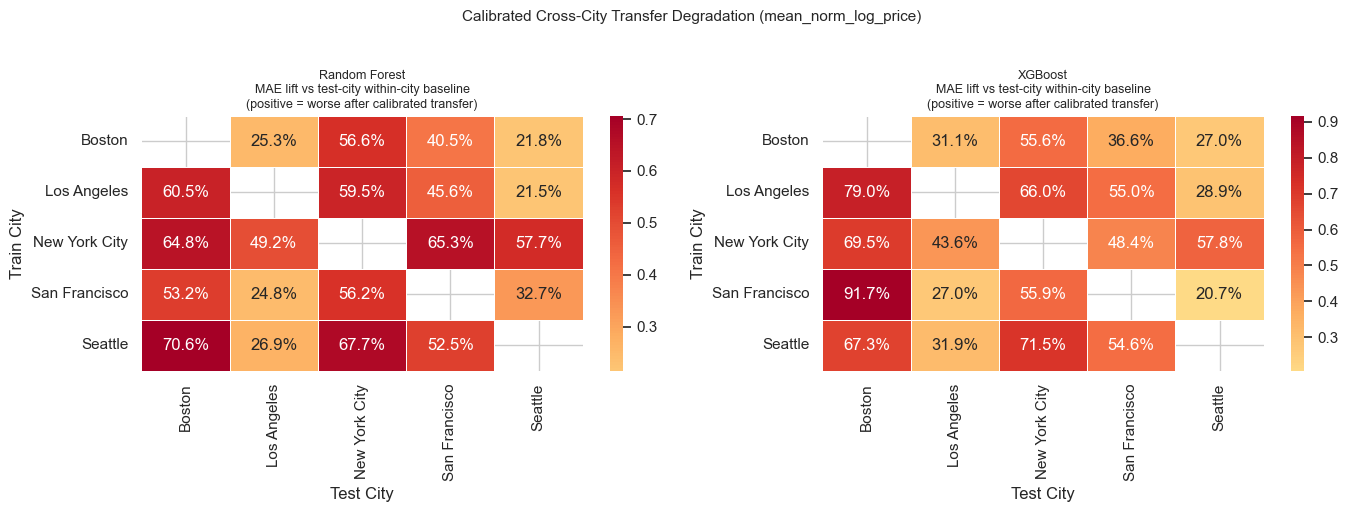

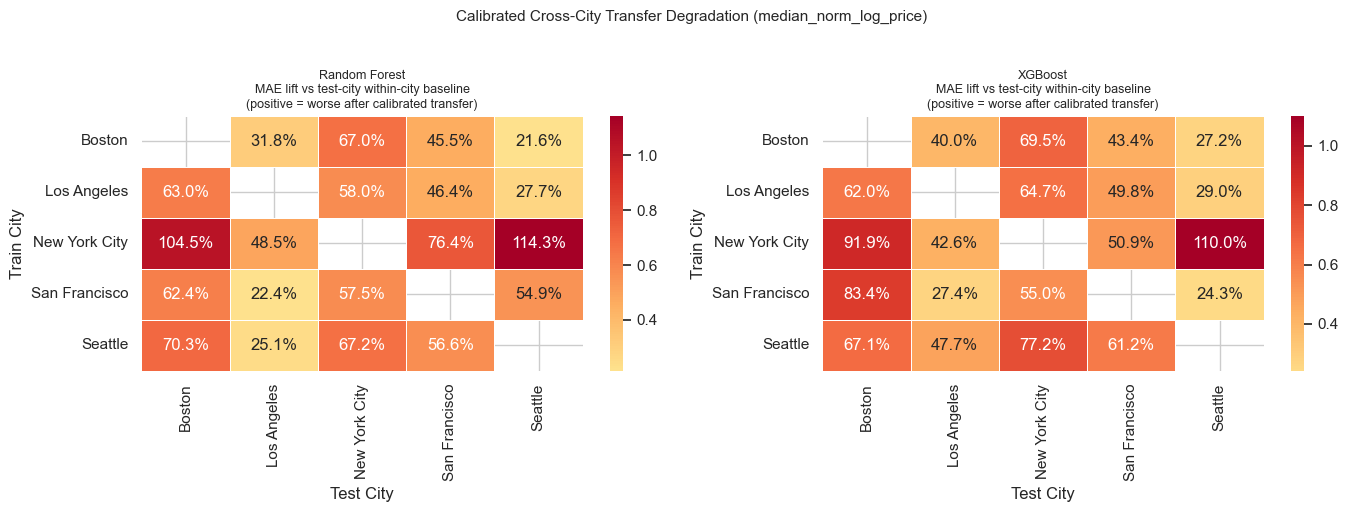

In [47]:
# Calibrated transfer degradation heatmaps
# Degradation = (calibrated transfer MAE - test-city within-city MAE)
#               / test-city within-city MAE

for target_variant in TARGET_VARIANTS:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, model_name in zip(axes, ["Random_Forest", "XGBoost"]):

        cross_slice = calibrated_summary[
            (calibrated_summary["Target_Variant"] == target_variant) &
            (calibrated_summary["Model"] == model_name)
        ][["Train_City", "Test_City", "MAE_mean"]].copy()

        within_ref = (
            within_city_mae[
                (within_city_mae["Target_Variant"] == target_variant) &
                (within_city_mae["Model"] == model_name)
            ]
            .set_index("City")["MAE_mean"]
            .to_dict()
        )

        cross_slice["Within_MAE"] = cross_slice["Test_City"].map(within_ref)

        cross_slice["Degradation"] = (
            (cross_slice["MAE_mean"] - cross_slice["Within_MAE"])
            / cross_slice["Within_MAE"]
        )

        deg_matrix = cross_slice.pivot(
            index="Train_City",
            columns="Test_City",
            values="Degradation"
        ).reindex(index=cities_all, columns=cities_all)

        sns.heatmap(
            deg_matrix,
            annot=True,
            fmt=".1%",
            cmap="RdYlGn_r",
            center=0,
            linewidths=0.5,
            ax=ax,
        )

        ax.set_title(
            f"{model_name.replace('_', ' ')}\n"
            f"MAE lift vs test-city within-city baseline\n"
            f"(positive = worse after calibrated transfer)",
            fontsize=9,
        )
        ax.set_xlabel("Test City")
        ax.set_ylabel("Train City")

    fig.suptitle(
        f"Calibrated Cross-City Transfer Degradation ({target_variant})",
        fontsize=11,
        y=1.02,
    )

    plt.tight_layout()
    plt.savefig(
        f"{RESULTS_DIR_CALIB}/tree__cross_city_calibrated_degradation"
        f"__{clean_name(target_variant)}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

In [48]:
# Grouping signal table — calibrated transfer
# Use mean_norm_log_price and median_norm_log_price because these
# are the variants where test-city calibration actually matters.

for main_variant in ["mean_norm_log_price", "median_norm_log_price"]:

    grouping_df_calib = calibrated_summary[
        calibrated_summary["Target_Variant"] == main_variant
    ][[
        "Train_City", "Test_City", "Model",
        "MAE_mean", "R2_mean", "Within_25pct_Error_mean",
        "Train_Anchor_Mean", "Train_Anchor_Median",
        "Test_Anchor_Mean", "Test_Anchor_Median",
    ]].copy()

    within_ref = (
        within_city_mae[
            within_city_mae["Target_Variant"] == main_variant
        ]
        .set_index(["City", "Model"])["MAE_mean"]
        .to_dict()
    )

    grouping_df_calib["Within_MAE"] = grouping_df_calib.apply(
        lambda r: within_ref.get((r["Test_City"], r["Model"]), np.nan),
        axis=1,
    )

    grouping_df_calib["MAE_Degradation"] = (
        (grouping_df_calib["MAE_mean"] - grouping_df_calib["Within_MAE"])
        / grouping_df_calib["Within_MAE"]
    )

    grouping_avg_calib = (
        grouping_df_calib
        .groupby(["Train_City", "Test_City"])
        [[
            "MAE_mean",
            "MAE_Degradation",
            "Within_25pct_Error_mean",
            "Train_Anchor_Mean",
            "Train_Anchor_Median",
            "Test_Anchor_Mean",
            "Test_Anchor_Median",
        ]]
        .mean()
        .round(3)
        .reset_index()
        .sort_values("MAE_Degradation")
    )

    print(f"\nCalibrated city-pair transfer quality — {main_variant}")
    print("Lower MAE_Degradation = better feature-transfer compatibility\n")

    display(grouping_avg_calib)

    grouping_avg_calib.to_csv(
        f"{RESULTS_DIR_CALIB}/tree__cross_city_calibrated_grouping_signal"
        f"__{clean_name(main_variant)}.csv",
        index=False,
    )

print("Calibrated grouping signal tables saved.")


Calibrated city-pair transfer quality — mean_norm_log_price
Lower MAE_Degradation = better feature-transfer compatibility



,Train_City,Test_City,MAE_mean,MAE_Degradation,Within_25pct_Error_mean,Train_Anchor_Mean,Train_Anchor_Median,Test_Anchor_Mean,Test_Anchor_Median
3,Boston,Seattle,60.012,0.244,0.496,244.041,202.0,179.384,148.0
7,Los Angeles,Seattle,60.422,0.252,0.499,227.168,154.0,179.384,148.0
13,San Francisco,Los Angeles,95.026,0.259,0.398,232.768,169.0,227.168,154.0
15,San Francisco,Seattle,61.132,0.267,0.495,232.768,169.0,179.384,148.0
0,Boston,Los Angeles,96.727,0.282,0.403,244.041,202.0,227.168,154.0
17,Seattle,Los Angeles,97.631,0.294,0.379,179.384,148.0,227.168,154.0
2,Boston,San Francisco,89.478,0.385,0.422,244.041,202.0,232.768,169.0
9,New York City,Los Angeles,110.515,0.464,0.320,219.501,150.0,227.168,154.0
6,Los Angeles,San Francisco,97.114,0.503,0.393,227.168,154.0,232.768,169.0
19,Seattle,San Francisco,99.220,0.536,0.366,179.384,148.0,232.768,169.0



Calibrated city-pair transfer quality — median_norm_log_price
Lower MAE_Degradation = better feature-transfer compatibility



,Train_City,Test_City,MAE_mean,MAE_Degradation,Within_25pct_Error_mean,Train_Anchor_Mean,Train_Anchor_Median,Test_Anchor_Mean,Test_Anchor_Median
3,Boston,Seattle,60.077,0.244,0.496,244.041,202.0,179.384,148.0
13,San Francisco,Los Angeles,94.110,0.249,0.419,232.768,169.0,227.168,154.0
7,Los Angeles,Seattle,61.993,0.284,0.468,227.168,154.0,179.384,148.0
0,Boston,Los Angeles,102.353,0.359,0.406,244.041,202.0,227.168,154.0
17,Seattle,Los Angeles,102.689,0.364,0.380,179.384,148.0,227.168,154.0
15,San Francisco,Seattle,67.454,0.396,0.451,232.768,169.0,179.384,148.0
2,Boston,San Francisco,93.496,0.445,0.413,244.041,202.0,232.768,169.0
9,New York City,Los Angeles,109.703,0.455,0.322,219.501,150.0,227.168,154.0
6,Los Angeles,San Francisco,95.842,0.481,0.383,227.168,154.0,232.768,169.0
14,San Francisco,New York City,102.578,0.563,0.358,232.768,169.0,219.501,150.0


Calibrated grouping signal tables saved.


Cross-city transfer usually performs worse than within-city prediction, but the degradation is not uniform. Some city pairs transfer reasonably well, while others fail badly, suggesting that Airbnb pricing rules are only partially shared across cities

Transfer performance is directional: training on city A and testing on city B is not necessarily equivalent to training on city B and testing on city A. This suggests that both feature distribution and learned pricing relationships matter

New York City appears to be a difficult transfer city

This suggests NYC pricing structure may be more city-specific. That is a strong discussion point, especially because NYC has unusual housing density, neighborhood structure, regulations, and room-type patterns


We first show that tree models improve within-city prediction, confirming that nonlinear feature interactions matter. Then we show that cross-city transfer causes meaningful degradation, but not equally across all city pairs. Some cities, such as Seattle and Los Angeles, transfer relatively well, while others, especially involving New York City, show much larger degradation. This suggests that Airbnb pricing contains both shared structure and city-specific pricing mechanisms

Mean/median city-level calibration should be treated as a separate experiment. The uncalibrated transfer setting tests pure model generalization. The calibrated setting tests whether giving the model target-city price-level information improves transfer and reveals more subtle feature-level failures





### Airbnb pricing models learn some transferable structure across cities, but transfer quality depends heavily on the city pair. Global price-level differences explain part of the failure, but some failures likely come from feature-value differences and city-specific pricing relationships

### Grouped Train with Tree Models

We train grouped models and evaluate them under a calibrated transfer setting, where test-city numeric features are aligned to the training distribution and predictions are re-anchored using the target city’s mean or median price

In [49]:
# Part A: Empirical-similarity grouped transfer
#   Group 1: LA + Seattle
#   Group 2: Boston + San Francisco
#   Group 3: LA + Seattle + San Francisco
#
# Part B: Leave-one-city-out grouped transfer (all 5 LOCO combos)
#
# Part C: Comparison table
#   For each target city: within-city vs best single-city vs grouped
#
# Primary model: XGBoost. Robustness check: Random Forest.
# All 3 target variants used throughout.
# Calibration: shift test-city numeric features to match group scaler means,
#              then denorm with test-city price anchor (same as Cell 54)
RESULTS_DIR_GROUP = "results/grouped"
MODEL_DIR_GROUP   = "saved_models/grouped"
os.makedirs(RESULTS_DIR_GROUP, exist_ok=True)
os.makedirs(MODEL_DIR_GROUP,   exist_ok=True)

cities_all = sorted(model_ready["city"].unique())

In [50]:
PART_A_GROUPS = {
    "LA_Seattle":           ["Los Angeles", "Seattle"],
    "Boston_SF":            ["Boston", "San Francisco"],
    "LA_Seattle_SF":        ["Los Angeles", "Seattle", "San Francisco"],
}

PART_B_GROUPS = {c: [x for x in cities_all if x != c] for c in cities_all}
# e.g. "Boston": ["Los Angeles", "New York City", "San Francisco", "Seattle"]

# combined: group_label -> train_cities list
ALL_GROUPS = {}
for label, cities in PART_A_GROUPS.items():
    ALL_GROUPS[f"A__{label}"] = cities
for test_city, train_cities in PART_B_GROUPS.items():
    ALL_GROUPS[f"B__LOCO_{clean_name(test_city)}"] = train_cities

# hyperparameter spaces (same as single-city tree models)
RF_PARAM_DIST = {
    "model__n_estimators":      randint(100, 500),
    "model__max_depth":         [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf":  randint(1, 10),
    "model__max_features":      ["sqrt", "log2", 0.5],
}
XGB_PARAM_DIST = {
    "model__n_estimators":     randint(100, 500),
    "model__max_depth":        randint(3, 10),
    "model__learning_rate":    uniform(0.01, 0.3),
    "model__subsample":        uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_alpha":        uniform(0, 1),
    "model__reg_lambda":       uniform(0.5, 2),
}
N_ITER       = 20
CV_INNER     = 3
RANDOM_STATE = 1003

MODEL_CONFIGS = [
    ("XGBoost",       XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), XGB_PARAM_DIST),
    ("Random_Forest", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),     RF_PARAM_DIST),
]



In [51]:
# calibrated prediction helper
def calibrated_predict(pipe, X_test_raw, test_price_vals,
                        target_variant, train_anchor_mean, train_anchor_median):
    """
    Mirror of Cell 54 calibration logic:
    1. Impute X_test with train-city imputer.
    2. Shift numeric features so test-city col means match train scaler means.
    3. Predict in variant space.
    4. Denorm with TEST-city price anchor.
    """
    num_transformer  = pipe.named_steps["prep"].named_transformers_["num"]
    train_feat_means = num_transformer.named_steps["scaler"].mean_
    num_imputer      = num_transformer.named_steps["imputer"]

    X_numeric = X_test_raw[numeric_features].copy()
    X_numeric_imputed = pd.DataFrame(
        num_imputer.transform(X_numeric),
        columns=numeric_features,
        index=X_numeric.index,
    )
    test_feat_means = X_numeric_imputed.mean().values
    shift = train_feat_means - test_feat_means

    X_test_shifted = X_test_raw.copy()
    X_test_shifted[numeric_features] = X_numeric_imputed.values + shift

    y_pred_v = pipe.predict(X_test_shifted)

    test_anchor_mean   = test_price_vals.mean()
    test_anchor_median = np.median(test_price_vals)

    if target_variant == "log_price":
        train_log_mean = np.log1p(train_anchor_mean)
        test_log_mean  = np.log1p(test_anchor_mean)
        y_pred_log     = y_pred_v + (test_log_mean - train_log_mean)
    elif target_variant == "mean_norm_log_price":
        y_pred_log = y_pred_v + np.log1p(test_anchor_mean)
    elif target_variant == "median_norm_log_price":
        y_pred_log = y_pred_v + np.log1p(test_anchor_median)

    return y_pred_log, test_anchor_mean, test_anchor_median

In [52]:
# Step 1 — Train grouped models and evaluate on held-out cities
grouped_results = []

for group_label, train_cities in ALL_GROUPS.items():
    part = group_label.split("__")[0]   # "A" or "B"

    # cities excluded from training = potential test cities
    if part == "A":
        test_cities = [c for c in cities_all if c not in train_cities]
    else:
        # LOCO: exactly one city excluded
        test_cities = [c for c in cities_all if c not in train_cities]

    # build group training dataframe
    group_df = model_ready[model_ready["city"].isin(train_cities)].copy()

    for target_variant in TARGET_VARIANTS:

        # compute group-level anchors for training target
        group_price       = np.expm1(group_df["log_price"].values)
        group_anchor_mean = group_price.mean()
        group_anchor_med  = np.median(group_price)

        if target_variant == "log_price":
            y_group = group_df["log_price"].values
        elif target_variant == "mean_norm_log_price":
            y_group = group_df["log_price"].values - np.log1p(group_anchor_mean)
        elif target_variant == "median_norm_log_price":
            y_group = group_df["log_price"].values - np.log1p(group_anchor_med)

        X_group = group_df[feature_cols]

        for model_name, base_estimator, param_dist in MODEL_CONFIGS:

            pipe = Pipeline([
                ("prep",  preprocessor),
                ("model", clone(base_estimator)),
            ])
            search = RandomizedSearchCV(
                pipe, param_distributions=param_dist,
                n_iter=N_ITER, cv=CV_INNER,
                scoring="neg_mean_squared_error",
                random_state=RANDOM_STATE, n_jobs=-1, refit=True,
            )
            search.fit(X_group, y_group)
            best_pipe = search.best_estimator_

            # save grouped model
            file_name = (
                f"grouped__group-{group_label}"
                f"__variant-{clean_name(target_variant)}"
                f"__model-{clean_name(model_name)}.joblib"
            )
            joblib.dump(
                {"pipe": best_pipe,
                 "anchor_mean": group_anchor_mean,
                 "anchor_median": group_anchor_med,
                 "train_cities": train_cities},
                f"{MODEL_DIR_GROUP}/{file_name}",
            )

            # evaluate on each test city with calibration
            for test_city in test_cities:
                test_df        = model_ready[model_ready["city"] == test_city].copy()
                X_test_raw     = test_df[feature_cols]
                y_log_test     = test_df["log_price"].values
                test_price_vals = test_df["price"].values

                y_pred_log, t_anchor_mean, t_anchor_med = calibrated_predict(
                    best_pipe, X_test_raw, test_price_vals,
                    target_variant, group_anchor_mean, group_anchor_med,
                )
                m = metrics_on_price(y_log_test, y_pred_log)

                grouped_results.append({
                    "Part":            part,
                    "Group_Label":     group_label,
                    "Train_Cities":    str(train_cities),
                    "Test_City":       test_city,
                    "Target_Variant":  target_variant,
                    "Model":           model_name,
                    "N_train":         len(group_df),
                    "N_test":          len(test_df),
                    "Train_Anchor_Mean":   group_anchor_mean,
                    "Train_Anchor_Median": group_anchor_med,
                    "Test_Anchor_Mean":    t_anchor_mean,
                    "Test_Anchor_Median":  t_anchor_med,
                    **m
                })

    print(f"  {group_label} done")

grouped_df = pd.DataFrame(grouped_results)
display(grouped_df.head(10))
print(f"\nTotal grouped results: {len(grouped_df)}")



  A__LA_Seattle done
  A__Boston_SF done
  A__LA_Seattle_SF done
  B__LOCO_Boston done
  B__LOCO_Los_Angeles done
  B__LOCO_New_York_City done
  B__LOCO_San_Francisco done
  B__LOCO_Seattle done


,Part,Group_Label,Train_Cities,Test_City,Target_Variant,Model,N_train,N_test,Train_Anchor_Mean,Train_Anchor_Median,Test_Anchor_Mean,Test_Anchor_Median,MAE,RMSE,Median_AE,R2,Spearman,Mean_Error,Overprice_Rate,Underprice_Rate,Within_25pct_Error,Within_50pct_Error
0,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",Boston,log_price,XGBoost,41954,3453,220.178171,152.0,244.040834,202.0,104.940172,168.443128,63.816655,0.195305,0.688701,-84.279100,0.262381,0.737619,0.339994,0.716768
1,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",New York City,log_price,XGBoost,41954,20675,220.178171,152.0,219.501137,150.0,109.061606,202.450459,43.931681,0.079340,0.655044,-80.799226,0.386505,0.613495,0.355550,0.654317
2,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",San Francisco,log_price,XGBoost,41954,5650,220.178171,152.0,232.768142,169.0,100.249737,179.280704,47.184777,0.264996,0.683101,-73.609885,0.336637,0.663363,0.398230,0.736814
3,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",Boston,log_price,Random_Forest,41954,3453,220.178171,152.0,244.040834,202.0,89.410182,146.955001,52.577217,0.387518,0.715959,-47.470136,0.432667,0.567333,0.400521,0.769186
4,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",New York City,log_price,Random_Forest,41954,20675,220.178171,152.0,219.501137,150.0,104.090987,194.048587,45.043860,0.154171,0.675828,-67.830647,0.432503,0.567497,0.372140,0.661040
5,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",San Francisco,log_price,Random_Forest,41954,5650,220.178171,152.0,232.768142,169.0,93.944582,168.801667,49.256602,0.348407,0.705230,-47.786515,0.495398,0.504602,0.396460,0.717345
6,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",Boston,mean_norm_log_price,XGBoost,41954,3453,220.178171,152.0,244.040834,202.0,104.940124,168.443080,63.816297,0.195306,0.688701,-84.279042,0.262381,0.737619,0.339994,0.716768
7,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",New York City,mean_norm_log_price,XGBoost,41954,20675,220.178171,152.0,219.501137,150.0,109.061598,202.450442,43.931625,0.079340,0.655045,-80.799233,0.386505,0.613495,0.355550,0.654317
8,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",San Francisco,mean_norm_log_price,XGBoost,41954,5650,220.178171,152.0,232.768142,169.0,100.249704,179.280659,47.184677,0.264996,0.683101,-73.609814,0.336637,0.663363,0.398230,0.736814
9,A,A__LA_Seattle,"['Los Angeles', 'Seattle']",Boston,mean_norm_log_price,Random_Forest,41954,3453,220.178171,152.0,244.040834,202.0,89.336947,147.063782,52.700190,0.386611,0.714679,-47.340902,0.433246,0.566754,0.397046,0.773241



Total grouped results: 78


In [53]:
# save
grouped_df.to_csv(f"{RESULTS_DIR_GROUP}/grouped__all_results.csv", index=False)
with pd.ExcelWriter(f"{RESULTS_DIR_GROUP}/grouped__all_results.xlsx") as writer:
    grouped_df.to_excel(writer, sheet_name="results", index=False)
print("Grouped results saved.")


Grouped results saved.


In [54]:
# Step 2 — Part C comparison table
# For each test city: within-city vs best single-city transfer vs grouped
# Primary metric: MAE (calibrated, mean_norm_log_price, XGBoost)

# within-city MAE from calibrated single-city results (calibrated_results_df)
# use mean_norm_log_price + XGBoost as primary comparison metric
PRIMARY_VARIANT = "mean_norm_log_price"
PRIMARY_MODEL   = "XGBoost"

# within-city: from tree_summary (within-city CV, no transfer needed)
within_city_ref = (
    tree_summary[
        (tree_summary["Train_City"] == tree_summary["Test_City"]) &
        (tree_summary["Target_Variant"] == PRIMARY_VARIANT) &
        (tree_summary["Model"] == PRIMARY_MODEL)
    ][["Test_City", "MAE_mean"]]
    .rename(columns={"Test_City": "City", "MAE_mean": "Within_City_MAE"})
    .set_index("City")
)

# best single-city calibrated transfer (from calibrated_results_df)
# for each test city, find the train city with lowest MAE
single_best = (
    calibrated_results_df[
        (calibrated_results_df["Target_Variant"] == PRIMARY_VARIANT) &
        (calibrated_results_df["Model"] == PRIMARY_MODEL)
    ]
    .groupby(["Test_City", "Train_City"])["MAE"]
    .mean()
    .reset_index()
    .sort_values("MAE")
    .groupby("Test_City")
    .first()
    .rename(columns={"MAE": "Best_Single_MAE", "Train_City": "Best_Single_TrainCity"})
)

# grouped LOCO MAE (Part B only — apples-to-apples with single-city transfer)
loco_grouped = (
    grouped_df[
        (grouped_df["Part"] == "B") &
        (grouped_df["Target_Variant"] == PRIMARY_VARIANT) &
        (grouped_df["Model"] == PRIMARY_MODEL)
    ][["Test_City", "MAE"]]
    .rename(columns={"MAE": "LOCO_Grouped_MAE"})
    .set_index("Test_City")
)

# Part A group results — for cities covered by each group
part_a_grouped = (
    grouped_df[
        (grouped_df["Part"] == "A") &
        (grouped_df["Target_Variant"] == PRIMARY_VARIANT) &
        (grouped_df["Model"] == PRIMARY_MODEL)
    ][["Group_Label", "Test_City", "MAE"]]
)

# build comparison table
comparison_rows = []
for city in cities_all:
    row = {"Test_City": city}

    # within-city
    row["Within_City_MAE"] = within_city_ref.loc[city, "Within_City_MAE"] if city in within_city_ref.index else np.nan

    # best single-city
    if city in single_best.index:
        row["Best_Single_MAE"]       = single_best.loc[city, "Best_Single_MAE"]
        row["Best_Single_TrainCity"] = single_best.loc[city, "Best_Single_TrainCity"]
    else:
        row["Best_Single_MAE"] = np.nan
        row["Best_Single_TrainCity"] = "-"

    # LOCO grouped
    row["LOCO_Grouped_MAE"] = loco_grouped.loc[city, "LOCO_Grouped_MAE"] if city in loco_grouped.index else np.nan

    # Part A grouped (show best Part A group that covers this test city)
    city_a = part_a_grouped[part_a_grouped["Test_City"] == city]
    if not city_a.empty:
        best_a = city_a.loc[city_a["MAE"].idxmin()]
        row["Best_PartA_MAE"]   = best_a["MAE"]
        row["Best_PartA_Group"] = best_a["Group_Label"]
    else:
        row["Best_PartA_MAE"]   = np.nan
        row["Best_PartA_Group"] = "-"

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("Test_City")

# derive gap metrics
comparison_df["LOCO_vs_Within_Gap"]      = comparison_df["LOCO_Grouped_MAE"] - comparison_df["Within_City_MAE"]
comparison_df["LOCO_vs_BestSingle_Gap"]  = comparison_df["LOCO_Grouped_MAE"] - comparison_df["Best_Single_MAE"]
# negative = grouped improved over best single; positive = grouped was worse

print(f"\nPart C Comparison Table ({PRIMARY_VARIANT}, {PRIMARY_MODEL})")
print("LOCO_vs_BestSingle_Gap < 0 means grouped beat best single-city source\n")
display(comparison_df.round(1))

comparison_df.to_csv(f"{RESULTS_DIR_GROUP}/grouped__part_c_comparison.csv")
print("Part C comparison saved.")



Part C Comparison Table (mean_norm_log_price, XGBoost)
LOCO_vs_BestSingle_Gap < 0 means grouped beat best single-city source



,Within_City_MAE,Best_Single_MAE,Best_Single_TrainCity,LOCO_Grouped_MAE,Best_PartA_MAE,Best_PartA_Group,LOCO_vs_Within_Gap,LOCO_vs_BestSingle_Gap
Test_City,,,,,,,,
Boston,57.8,96.7,Seattle,92.9,104.9,A__LA_Seattle,35.1,-3.8
Los Angeles,74.5,94.6,San Francisco,96.0,92.6,A__Boston_SF,21.5,1.4
New York City,65.7,102.2,Boston,108.2,101.5,A__Boston_SF,42.5,6.0
San Francisco,64.8,88.5,Boston,99.0,100.2,A__LA_Seattle,34.2,10.6
Seattle,48.1,58.1,San Francisco,65.1,59.7,A__Boston_SF,17.0,7.0


Part C comparison saved.


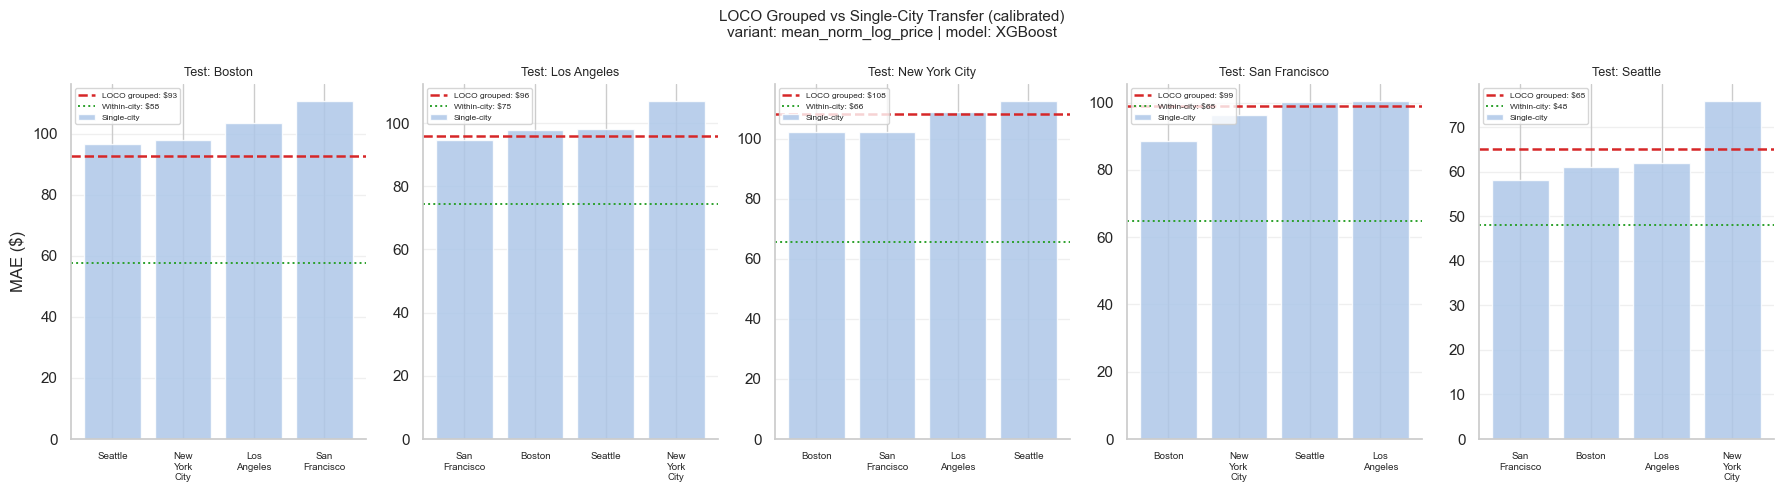

In [55]:
# Step 3 — Visualizations

# Part B LOCO: grouped vs single-city MAE per test city
fig, axes = plt.subplots(1, len(cities_all), figsize=(18, 5), sharey=False)

for ax, test_city in zip(axes, cities_all):
    # single-city calibrated MAE for all train cities
    singles = calibrated_results_df[
        (calibrated_results_df["Test_City"] == test_city) &
        (calibrated_results_df["Target_Variant"] == PRIMARY_VARIANT) &
        (calibrated_results_df["Model"] == PRIMARY_MODEL)
    ][["Train_City", "MAE"]].sort_values("MAE")

    bars = ax.bar(singles["Train_City"], singles["MAE"],
                  color="#aec7e8", alpha=0.85, label="Single-city")
    ax.set_xticklabels(
        [c.replace(" ", "\n") for c in singles["Train_City"]],
        fontsize=7, rotation=0,
    )

    # LOCO grouped line
    if test_city in loco_grouped.index:
        loco_mae = loco_grouped.loc[test_city, "LOCO_Grouped_MAE"]
        ax.axhline(loco_mae, color="#d62728", linewidth=1.8,
                   linestyle="--", label=f"LOCO grouped: ${loco_mae:.0f}")

    # within-city line
    if test_city in within_city_ref.index:
        wc_mae = within_city_ref.loc[test_city, "Within_City_MAE"]
        ax.axhline(wc_mae, color="#2ca02c", linewidth=1.4,
                   linestyle=":", label=f"Within-city: ${wc_mae:.0f}")

    ax.set_title(f"Test: {test_city}", fontsize=9)
    ax.set_ylabel("MAE ($)" if test_city == cities_all[0] else "")
    ax.legend(fontsize=6)
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle(
    f"LOCO Grouped vs Single-City Transfer (calibrated)\n"
    f"variant: {PRIMARY_VARIANT} | model: {PRIMARY_MODEL}",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_GROUP}/grouped__partB_loco_vs_single.png",
            dpi=150, bbox_inches="tight")
plt.show()



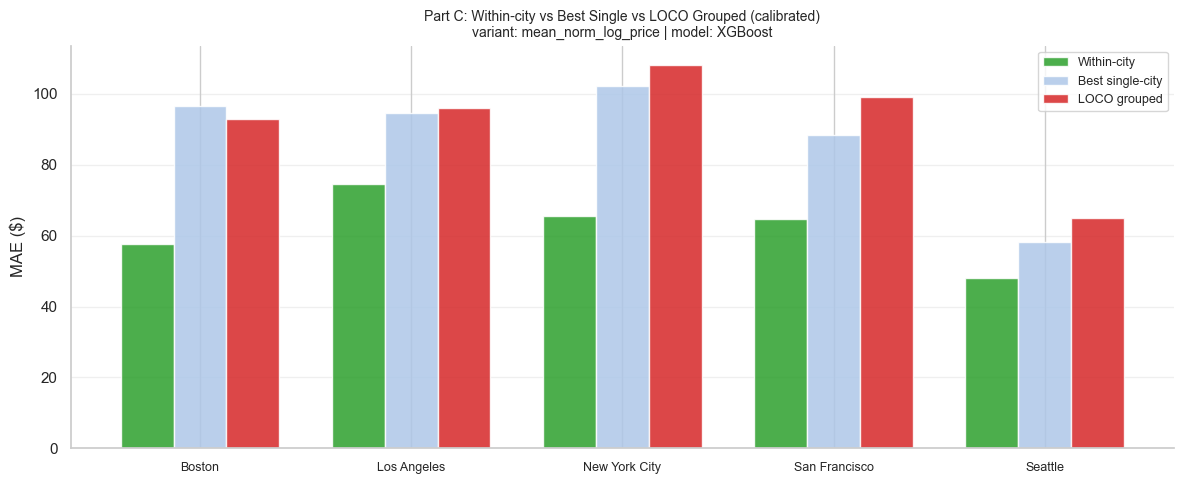

In [56]:
# 3b. Part C summary bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(cities_all))
width = 0.25

ax.bar(x - width, comparison_df["Within_City_MAE"],    width, label="Within-city",      color="#2ca02c", alpha=0.85)
ax.bar(x,         comparison_df["Best_Single_MAE"],    width, label="Best single-city",  color="#aec7e8", alpha=0.85)
ax.bar(x + width, comparison_df["LOCO_Grouped_MAE"],   width, label="LOCO grouped",      color="#d62728", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cities_all, fontsize=9)
ax.set_ylabel("MAE ($)")
ax.set_title(
    f"Part C: Within-city vs Best Single vs LOCO Grouped (calibrated)\n"
    f"variant: {PRIMARY_VARIANT} | model: {PRIMARY_MODEL}",
    fontsize=10,
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_GROUP}/grouped__partC_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()

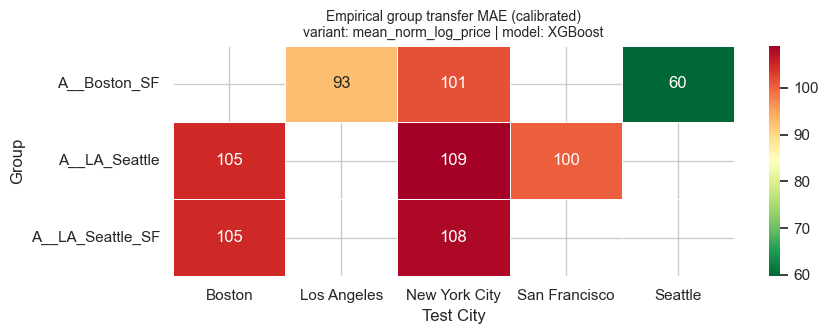

In [57]:
# ── 3c. Part A: grouped transfer MAE heatmap (group × test city) ─────────────
part_a_pivot = (
    grouped_df[
        (grouped_df["Part"] == "A") &
        (grouped_df["Target_Variant"] == PRIMARY_VARIANT) &
        (grouped_df["Model"] == PRIMARY_MODEL)
    ]
    .pivot_table(index="Group_Label", columns="Test_City", values="MAE", aggfunc="mean")
)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(part_a_pivot, annot=True, fmt=".0f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax)
ax.set_title(
    f"Empirical group transfer MAE (calibrated)\n"
    f"variant: {PRIMARY_VARIANT} | model: {PRIMARY_MODEL}",
    fontsize=10,
)
ax.set_xlabel("Test City")
ax.set_ylabel("Group")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_GROUP}/grouped__partA_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()



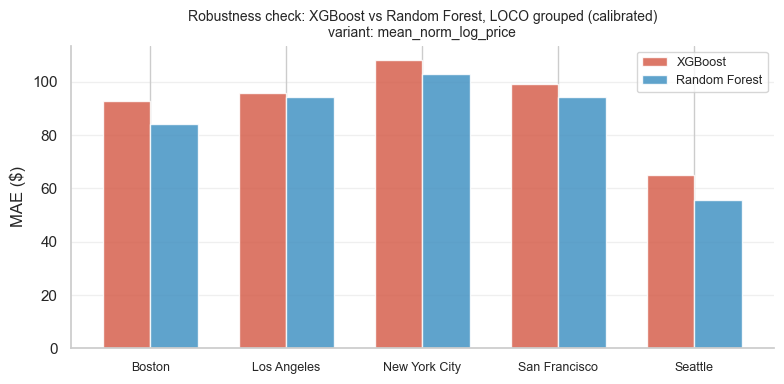


All grouped-city transfer experiments complete.
Results in: results/grouped/
Models in:  saved_models/grouped/


In [58]:
# Robustness: XGBoost vs Random Forest LOCO comparison
rf_loco = (
    grouped_df[
        (grouped_df["Part"] == "B") &
        (grouped_df["Target_Variant"] == PRIMARY_VARIANT) &
        (grouped_df["Model"] == "Random_Forest")
    ][["Test_City", "MAE"]]
    .rename(columns={"MAE": "RF_LOCO_MAE"})
    .set_index("Test_City")
)

xgb_loco = loco_grouped.rename(columns={"LOCO_Grouped_MAE": "XGB_LOCO_MAE"})

robustness_df = pd.concat([xgb_loco, rf_loco], axis=1).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
x     = np.arange(len(robustness_df))
width = 0.35
ax.bar(x - width/2, robustness_df["XGB_LOCO_MAE"], width,
       label="XGBoost", color="#d6604d", alpha=0.85)
ax.bar(x + width/2, robustness_df["RF_LOCO_MAE"],  width,
       label="Random Forest", color="#4393c3", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(robustness_df["Test_City"], fontsize=9)
ax.set_ylabel("MAE ($)")
ax.set_title(
    f"Robustness check: XGBoost vs Random Forest, LOCO grouped (calibrated)\n"
    f"variant: {PRIMARY_VARIANT}",
    fontsize=10,
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_GROUP}/grouped__robustness_xgb_vs_rf.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nAll grouped-city transfer experiments complete.")
print(f"Results in: {RESULTS_DIR_GROUP}/")
print(f"Models in:  {MODEL_DIR_GROUP}/")
# files written:
#   grouped__all_results.csv / .xlsx
#   grouped__part_c_comparison.csv
#   grouped__partB_loco_vs_single.png
#   grouped__partC_summary.png
#   grouped__partA_heatmap.png
#   grouped__robustness_xgb_vs_rf.png

## MLP - Feed-forward Neural Network

We evaluate MLP primarily in the grouped-city setting rather than running all single-city transfer pairs. This choice is motivated by both computational efficiency and model stability. Compared with tree-based models, MLPs typically require more data and more careful tuning. Some individual cities in our dataset, such as Boston, San Francisco, and Seattle, contain substantially fewer listings than Los Angeles or New York City, making single-city neural network training more prone to overfitting and unstable performance. Grouped-city training provides a larger and more diverse training set, which better matches the purpose of using MLPs: testing whether a higher-capacity model can learn transferable pricing patterns across cities.

Does a higher-capacity neural network improve grouped-city transfer compared with tree models?

Run: LOCO grouped-city MLP - Train on 4 cities → test on held-out city

ALSO

Train: Los Angeles + Seattle and Test: Boston, NYC, San Francisco

Train: Boston + San Francisco and Test: Los Angeles, NYC, Seattle

TARGET: mean_norm_log_price, log_price, median_norm_log_price

Hyperparameter Tuning: keep it simple as we only want to see if more complex model is helpful, not to achieve the best performance

Remember to USE GridSearchCV and do not shift numeric features

In [59]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import copy

In [60]:
RESULTS_DIR_MLP = "results/mlp"
MODEL_DIR_MLP   = "saved_models/mlp"
os.makedirs(RESULTS_DIR_MLP, exist_ok=True)
os.makedirs(MODEL_DIR_MLP,   exist_ok=True)

RANDOM_STATE = 1003
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [61]:
class PriceMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def train_mlp(X_train_np, y_train_np, X_val_np, y_val_np,
              lr=1e-3, dropout=0.3, epochs=200, batch_size=512, patience=15):
    input_dim = X_train_np.shape[1]
    model     = PriceMLP(input_dim, dropout=dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()

    X_tr = torch.FloatTensor(X_train_np).to(device)
    y_tr = torch.FloatTensor(y_train_np).to(device)
    X_vl = torch.FloatTensor(X_val_np).to(device)
    y_vl = torch.FloatTensor(y_val_np).to(device)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl), y_vl).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = copy.deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


def predict_mlp(model, X_np):
    model.eval()
    with torch.no_grad():
        return model(torch.FloatTensor(X_np).to(device)).cpu().numpy()


In [62]:
HP_CANDIDATES = [
    {"lr": 1e-3,  "dropout": 0.2},
    {"lr": 1e-3,  "dropout": 0.3},
    {"lr": 5e-4,  "dropout": 0.3},
]

MLP_GROUPS = {
    "LOCO_Boston":        [c for c in cities_all if c != "Boston"],
    "LOCO_Los_Angeles":   [c for c in cities_all if c != "Los Angeles"],
    "LOCO_New_York_City": [c for c in cities_all if c != "New York City"],
    "LOCO_San_Francisco": [c for c in cities_all if c != "San Francisco"],
    "LOCO_Seattle":       [c for c in cities_all if c != "Seattle"],
    "A__LA_Seattle":      ["Los Angeles", "Seattle"],
    "A__Boston_SF":       ["Boston", "San Francisco"],
}


In [ ]:
mlp_results = []
mlp_hp_log  = []

for group_label, train_cities in MLP_GROUPS.items():

    part        = "B" if group_label.startswith("LOCO") else "A"
    test_cities = [c for c in cities_all if c not in train_cities]
    group_df    = model_ready[model_ready["city"].isin(train_cities)].copy()

    for target_variant in TARGET_VARIANTS:

        group_price       = np.expm1(group_df["log_price"].values)
        group_anchor_mean = group_price.mean()
        group_anchor_med  = np.median(group_price)

        if target_variant == "log_price":
            y_group = group_df["log_price"].values
        elif target_variant == "mean_norm_log_price":
            y_group = group_df["log_price"].values - np.log1p(group_anchor_mean)
        elif target_variant == "median_norm_log_price":
            y_group = group_df["log_price"].values - np.log1p(group_anchor_med)

        # fit preprocessor on group data (all 100% — scaler sees full group distribution)
        prep         = copy.deepcopy(preprocessor)
        X_group_proc = prep.fit_transform(group_df[feature_cols]).astype(np.float32)
        y_group      = y_group.astype(np.float32)

        # 60/20/20 split: train / val (early stopping) / in-group test
        rng      = np.random.default_rng(RANDOM_STATE)
        idx      = rng.permutation(len(X_group_proc))
        n        = len(idx)
        n_train  = int(0.6 * n)
        n_val    = int(0.2 * n)
        # remaining 20% is in-group test

        train_idx   = idx[:n_train]
        val_idx     = idx[n_train:n_train + n_val]
        intest_idx  = idx[n_train + n_val:]

        X_tr_np = X_group_proc[train_idx]
        y_tr_np = y_group[train_idx]
        X_vl_np = X_group_proc[val_idx]
        y_vl_np = y_group[val_idx]
        X_it_np = X_group_proc[intest_idx]
        y_it_np = y_group[intest_idx]           # in variant space
        y_it_log = group_df["log_price"].values[intest_idx]  # original log_price for eval

        # select best hp on validation loss
        best_hp      = None
        best_vl_loss = float("inf")
        best_model   = None

        for hp in HP_CANDIDATES:
            model, vl_loss = train_mlp(X_tr_np, y_tr_np, X_vl_np, y_vl_np,
                                       lr=hp["lr"], dropout=hp["dropout"])
            mlp_hp_log.append({
                "Group_Label": group_label, "Target_Variant": target_variant,
                **hp, "Val_MSE": vl_loss,
            })
            if vl_loss < best_vl_loss:
                best_vl_loss = vl_loss
                best_hp      = hp
                best_model   = model

        final_model = best_model

        # evaluate on in-group test split (20%)
        y_it_pred_v = predict_mlp(final_model, X_it_np)
        if target_variant == "log_price":
            y_it_pred_log = y_it_pred_v
        elif target_variant == "mean_norm_log_price":
            y_it_pred_log = y_it_pred_v + np.log1p(group_anchor_mean)
        elif target_variant == "median_norm_log_price":
            y_it_pred_log = y_it_pred_v + np.log1p(group_anchor_med)

        m_intest = metrics_on_price(y_it_log, y_it_pred_log)

        # save model and preprocessor
        torch.save(
            final_model.state_dict(),
            f"{MODEL_DIR_MLP}/mlp__group-{group_label}__variant-{clean_name(target_variant)}__model.pt",
        )
        joblib.dump(
            {"prep": prep, "input_dim": X_group_proc.shape[1],
             "anchor_mean": group_anchor_mean, "anchor_median": group_anchor_med,
             "train_cities": train_cities, "best_hp": best_hp,
             "ingroup_test_mae": m_intest["MAE"]},
            f"{MODEL_DIR_MLP}/mlp__group-{group_label}__variant-{clean_name(target_variant)}__meta.joblib",
        )

        # evaluate on held-out test cities — strict OOD, no feature shift, train-city anchor
        for test_city in test_cities:
            test_df            = model_ready[model_ready["city"] == test_city].copy()
            X_test_proc        = prep.transform(test_df[feature_cols]).astype(np.float32)
            y_log_test         = test_df["log_price"].values
            test_price_vals    = test_df["price"].values
            test_anchor_mean   = test_price_vals.mean()
            test_anchor_median = np.median(test_price_vals)

            y_pred_v = predict_mlp(final_model, X_test_proc)

            if target_variant == "log_price":
                y_pred_log = y_pred_v
            elif target_variant == "mean_norm_log_price":
                y_pred_log = y_pred_v + np.log1p(group_anchor_mean)
            elif target_variant == "median_norm_log_price":
                y_pred_log = y_pred_v + np.log1p(group_anchor_med)

            m = metrics_on_price(y_log_test, y_pred_log)

            mlp_results.append({
                "Experiment":           "mlp_grouped_transfer",
                "Part":                 part,
                "Group_Label":          group_label,
                "Train_Cities":         str(train_cities),
                "Test_City":            test_city,
                "Eval_Type":            "held_out_city",
                "Target_Variant":       target_variant,
                "Model":                "MLP",
                "Best_LR":              best_hp["lr"],
                "Best_Dropout":         best_hp["dropout"],
                "N_train":              len(train_idx),
                "N_val":                len(val_idx),
                "N_ingroup_test":       len(intest_idx),
                "N_held_out_test":      len(test_df),
                "InGroup_Test_MAE":     m_intest["MAE"],
                "Train_Anchor_Mean":    group_anchor_mean,
                "Train_Anchor_Median":  group_anchor_med,
                "Test_Anchor_Mean":     test_anchor_mean,
                "Test_Anchor_Median":   test_anchor_median,
                **m
            })

    print(f"  {group_label} done")


In [ ]:
mlp_df    = pd.DataFrame(mlp_results)
mlp_hp_df = pd.DataFrame(mlp_hp_log)
display(mlp_df.head(10))
print(f"\nTotal MLP results: {len(mlp_df)}")

mlp_df.to_csv(f"{RESULTS_DIR_MLP}/mlp__all_results.csv", index=False)
mlp_hp_df.to_csv(f"{RESULTS_DIR_MLP}/mlp__hp_log.csv", index=False)
with pd.ExcelWriter(f"{RESULTS_DIR_MLP}/mlp__all_results.xlsx") as writer:
    mlp_df.to_excel(writer,    sheet_name="results", index=False)
    mlp_hp_df.to_excel(writer, sheet_name="hp_log",  index=False)
print("MLP results saved.")


In [ ]:
# comparison: MLP LOCO vs tree Test 1 (strict OOD, log_price)
COMP_VARIANT = "log_price"

tree_singles = (
    transfer_results_df[
        (transfer_results_df["Target_Variant"] == COMP_VARIANT) &
        (transfer_results_df["Model"] == "XGBoost")
    ]
    .groupby(["Train_City", "Test_City"])["MAE"]
    .mean()
    .reset_index()
)

mlp_loco = (
    mlp_df[
        (mlp_df["Part"] == "B") &
        (mlp_df["Target_Variant"] == COMP_VARIANT)
    ][["Test_City", "MAE"]]
    .rename(columns={"MAE": "MLP_LOCO_MAE"})
    .set_index("Test_City")
)

within_ref = (
    tree_summary[
        (tree_summary["Train_City"] == tree_summary["Test_City"]) &
        (tree_summary["Target_Variant"] == COMP_VARIANT) &
        (tree_summary["Model"] == "XGBoost")
    ][["Test_City", "MAE_mean"]]
    .rename(columns={"Test_City": "City", "MAE_mean": "Within_City_MAE"})
    .set_index("City")
)

tree_best_single = tree_singles.groupby("Test_City")["MAE"].min().rename("Tree_BestSingle_MAE")

comp_df = pd.concat([within_ref, tree_best_single, mlp_loco], axis=1).round(1)
comp_df["MLP_vs_TreeBestSingle"] = (comp_df["MLP_LOCO_MAE"] - comp_df["Tree_BestSingle_MAE"]).round(1)

print(f"\nMLP vs Tree: strict OOD ({COMP_VARIANT})")
print("MLP_vs_TreeBestSingle < 0 → MLP LOCO beats best single-city tree\n")
display(comp_df)
comp_df.to_csv(f"{RESULTS_DIR_MLP}/mlp__vs_tree_comparison.csv")

In [ ]:
# visualization 1: LOCO — MLP vs tree single-city per test city
fig, axes = plt.subplots(1, len(cities_all), figsize=(18, 5), sharey=False)
for ax, test_city in zip(axes, cities_all):
    singles = tree_singles[tree_singles["Test_City"] == test_city].sort_values("MAE").reset_index(drop=True)
    x_pos   = np.arange(len(singles))
    ax.bar(x_pos, singles["MAE"], color="#aec7e8", alpha=0.85, label="Tree single-city (XGB)")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([c.replace(" ", "\n") for c in singles["Train_City"]], fontsize=7, rotation=0)

    if test_city in mlp_loco.index:
        mlp_mae = mlp_loco.loc[test_city, "MLP_LOCO_MAE"]
        ax.axhline(mlp_mae, color="#9467bd", linewidth=1.8, linestyle="--", label=f"MLP LOCO: ${mlp_mae:.0f}")
    if test_city in within_ref.index:
        wc_mae = within_ref.loc[test_city, "Within_City_MAE"]
        ax.axhline(wc_mae, color="#2ca02c", linewidth=1.4, linestyle=":", label=f"Within-city: ${wc_mae:.0f}")

    ax.set_title(f"Test: {test_city}", fontsize=9)
    ax.set_ylabel("MAE ($)" if test_city == cities_all[0] else "")
    ax.legend(fontsize=6)
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle(f"MLP LOCO grouped vs tree single-city (strict OOD)\nvariant: {COMP_VARIANT}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_MLP}/mlp__loco_vs_tree_single.png", dpi=150, bbox_inches="tight")
plt.show()



In [ ]:
# visualization 2: Part A — MLP vs XGBoost empirical groups
part_a_mlp  = mlp_df[(mlp_df["Part"] == "A") & (mlp_df["Target_Variant"] == COMP_VARIANT)][["Group_Label", "Test_City", "MAE"]].copy()
part_a_tree = grouped_df[(grouped_df["Part"] == "A") & (grouped_df["Target_Variant"] == COMP_VARIANT) & (grouped_df["Model"] == "XGBoost")][["Group_Label", "Test_City", "MAE"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (group_label, group_name) in zip(axes, [("A__LA_Seattle", "LA + Seattle"), ("A__Boston_SF", "Boston + SF")]):
    mlp_sub  = part_a_mlp[part_a_mlp["Group_Label"] == group_label].set_index("Test_City")["MAE"]
    tree_sub = part_a_tree[part_a_tree["Group_Label"] == group_label].set_index("Test_City")["MAE"]
    test_c   = sorted(set(mlp_sub.index) | set(tree_sub.index))
    x        = np.arange(len(test_c))
    width    = 0.35
    ax.bar(x - width/2, [tree_sub.get(c, np.nan) for c in test_c], width, label="XGBoost", color="#d6604d", alpha=0.85)
    ax.bar(x + width/2, [mlp_sub.get(c, np.nan)  for c in test_c], width, label="MLP",     color="#9467bd", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(test_c, fontsize=9)
    ax.set_title(f"Group: {group_name}", fontsize=10)
    ax.set_ylabel("MAE ($)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    sns.despine(ax=ax)

fig.suptitle(f"MLP vs XGBoost empirical group transfer (strict OOD)\nvariant: {COMP_VARIANT}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR_MLP}/mlp__partA_vs_tree.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMLP experiments complete.")
# files written:
#   mlp__all_results.csv / .xlsx (sheets: results, hp_log)
#   mlp__hp_log.csv
#   mlp__vs_tree_comparison.csv
#   mlp__loco_vs_tree_single.png
#   mlp__partA_vs_tree.png
# saved models (per group × variant):
#   mlp__group-{label}__variant-{v}__model.pt     (PyTorch state dict)
#   mlp__group-{label}__variant-{v}__meta.joblib  (preprocessor + anchors)